# 1. EDA

### 1. Импорт библиотек

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Установим стиль графиков
plt.style.use('seaborn-v0_8-darkgrid')

### 2. Загрузка данных

In [208]:
# Замените путь на свой
train = pd.read_csv('tr_for_students.csv')
test = pd.read_csv('vl_for_students.csv', encoding='mac_cyrillic', sep=';')

# Преобразование даты

train['issue_d'] = pd.to_datetime(train['issue_d'])
test['issue_d'] = pd.to_datetime(test['issue_d'])

### 3. Базовая информация

In [209]:
print("Размер обучающей выборки:", train.shape)
print("Размер тестовой выборки:", test.shape)

print("\nТипы данных в train:")
print(train.dtypes)

Размер обучающей выборки: (61169, 23)
Размер тестовой выборки: (60332, 23)

Типы данных в train:
issue_d                     datetime64[ns]
purpose                             object
addr_state                          object
sub_grade                           object
home_ownership                      object
emp_title                           object
installment                        float64
dti                                float64
funded_amnt                          int64
annual_inc                         float64
emp_length                         float64
term                                 int64
inq_last_6mths                       int64
mths_since_recent_inq              float64
delinq_2yrs                          int64
chargeoff_within_12_mths             int64
num_accts_ever_120_pd              float64
num_tl_90g_dpd_24m                 float64
acc_open_past_24mths               float64
avg_cur_bal                        float64
tot_hi_cred_lim                    float64


### 4. Распределение целевой переменной (def)

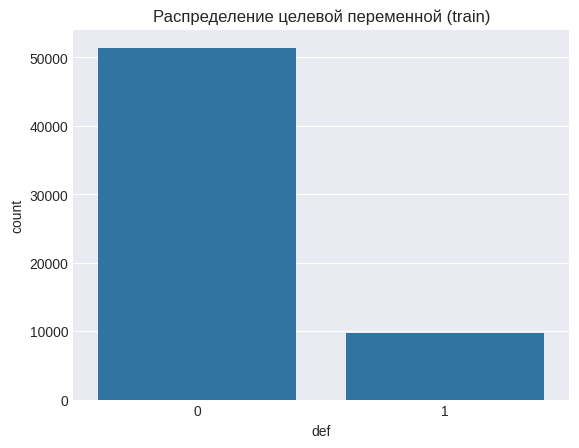

In [210]:
sns.countplot(x='def', data=train)
plt.title('Распределение целевой переменной (train)')
plt.show()

### 5. Динамика дефолтов по месяцам

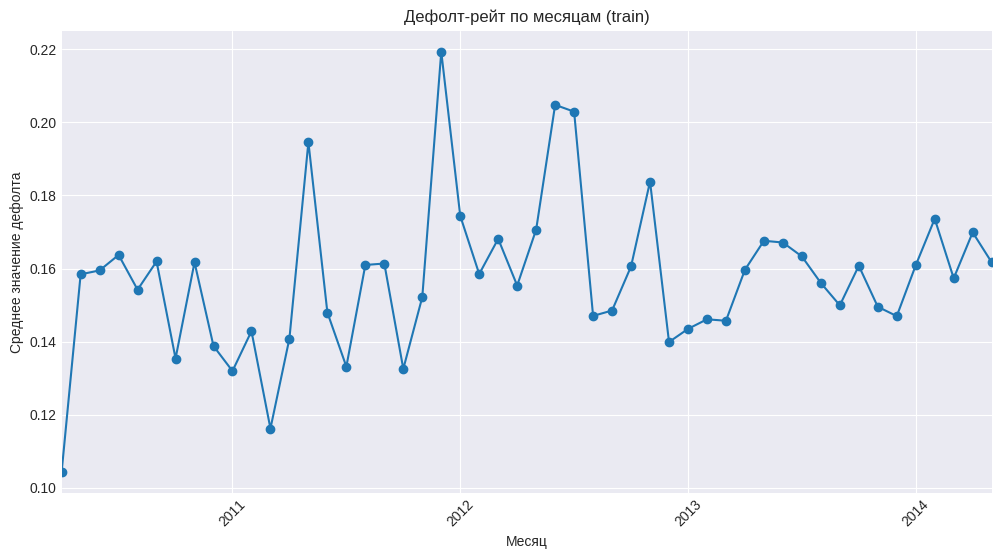

In [211]:
train['issue_month'] = train['issue_d'].dt.to_period('M')
default_rate_by_month = train.groupby('issue_month')['def'].mean()

plt.figure(figsize=(12,6))
default_rate_by_month.plot(marker='o')
plt.title('Дефолт-рейт по месяцам (train)')
plt.ylabel('Среднее значение дефолта')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.show()

### 6. Сравнение дефолт-рейта на трейне и тесте

Проверим, насколько стабильно распределение целевой переменной между выборками.

In [212]:
train_rate = train['def'].mean()
test_rate = test['def'].mean()
print(f"Дефолт-рейт на трейне: {train_rate:.4f}")
print(f"Дефолт-рейт на тесте: {test_rate:.4f}")

Дефолт-рейт на трейне: 0.1596
Дефолт-рейт на тесте: 0.1767


### 7. Распределение заявок по месяцам

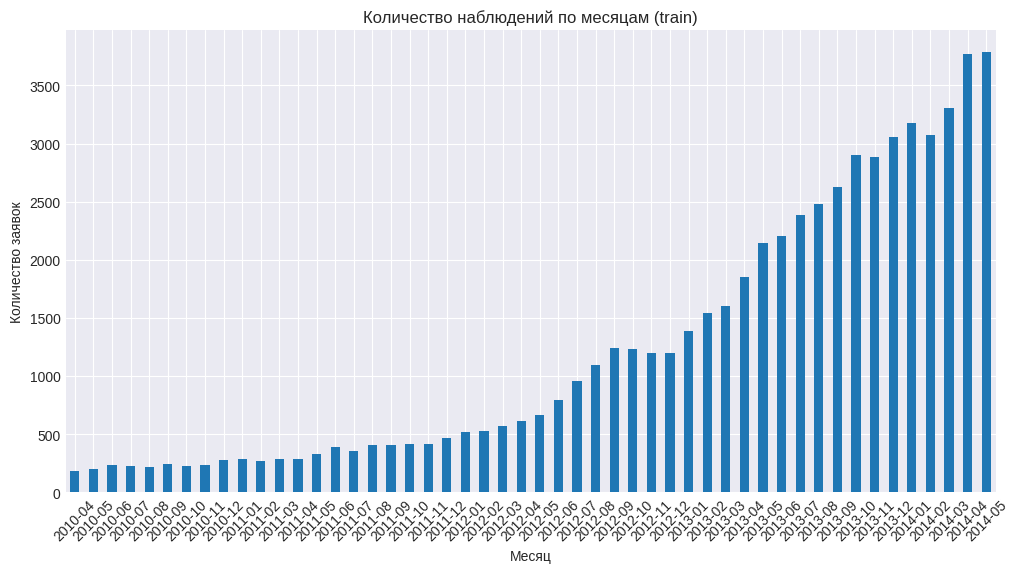

In [213]:
obs_by_month = train['issue_month'].value_counts().sort_index()

plt.figure(figsize=(12,6))
obs_by_month.plot(kind='bar')
plt.title('Количество наблюдений по месяцам (train)')
plt.ylabel('Количество заявок')
plt.xlabel('Месяц')
plt.xticks(rotation=45)
plt.show()

### 8. Пропуски в данных

Доля пропущенных значений по признакам:
mths_since_recent_inq       0.221174
avg_cur_bal                 0.195279
num_tl_90g_dpd_24m          0.195213
num_accts_ever_120_pd       0.195213
tot_hi_cred_lim             0.195213
acc_open_past_24mths        0.128922
emp_title                   0.063186
emp_length                  0.043715
dti                         0.000000
installment                 0.000000
home_ownership              0.000000
sub_grade                   0.000000
purpose                     0.000000
addr_state                  0.000000
issue_d                     0.000000
annual_inc                  0.000000
chargeoff_within_12_mths    0.000000
delinq_2yrs                 0.000000
inq_last_6mths              0.000000
term                        0.000000
funded_amnt                 0.000000
delinq_amnt                 0.000000
def                         0.000000
issue_month                 0.000000
dtype: float64


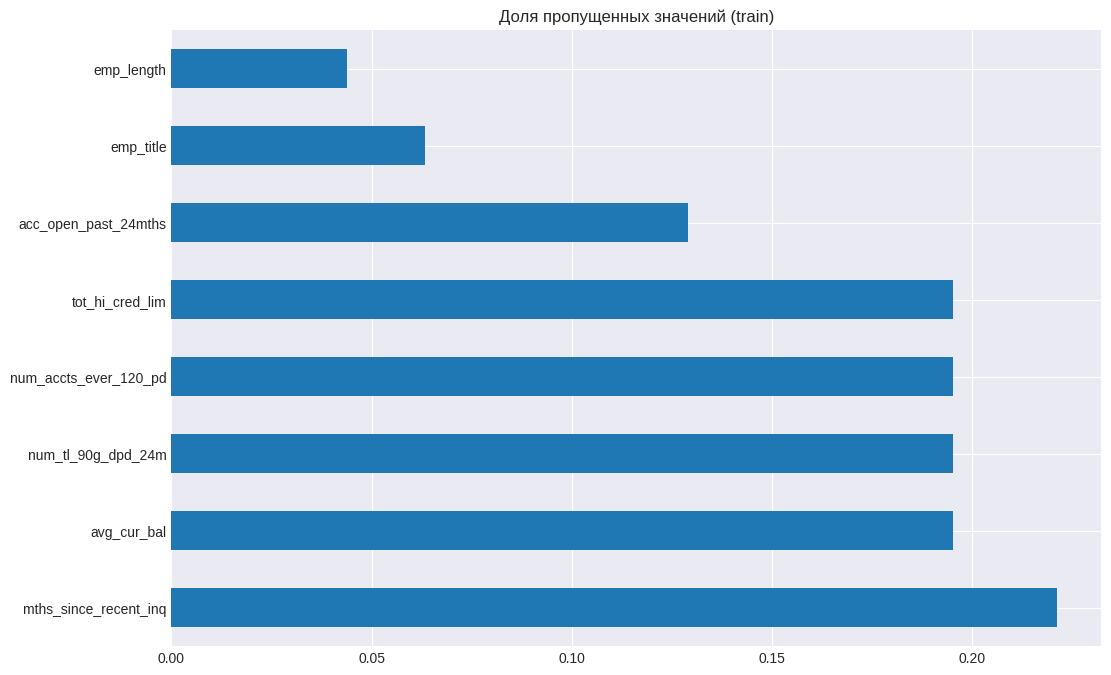

In [214]:
missing_values = train.isnull().mean().sort_values(ascending=False)
print("Доля пропущенных значений по признакам:")
print(missing_values)

plt.figure(figsize=(12,8))
missing_values[missing_values > 0].plot(kind='barh')
plt.title('Доля пропущенных значений (train)')
plt.show()

### 9. Уникальные значения признаков

In [215]:
unique_counts = train.nunique().sort_values()
print("Количество уникальных значений по признакам:")
print(unique_counts)

Количество уникальных значений по признакам:
term                            2
def                             2
chargeoff_within_12_mths        4
home_ownership                  5
inq_last_6mths                  9
emp_length                     11
purpose                        14
num_accts_ever_120_pd          18
num_tl_90g_dpd_24m             18
delinq_2yrs                    19
mths_since_recent_inq          25
acc_open_past_24mths           26
sub_grade                      35
addr_state                     47
issue_d                        50
issue_month                    50
delinq_amnt                   110
funded_amnt                  1183
dti                          3484
annual_inc                   6473
installment                 20212
avg_cur_bal                 24791
emp_title                   38576
tot_hi_cred_lim             41613
dtype: int64


### 10. Зависимость дефолта от дня недели и месяца

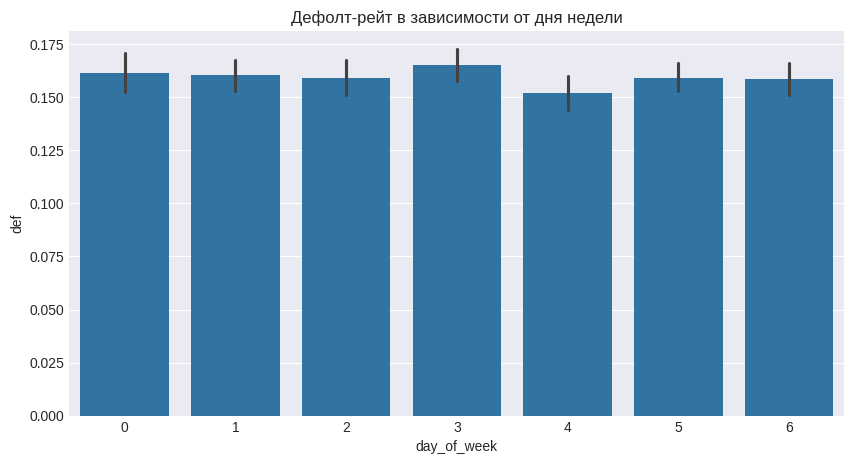

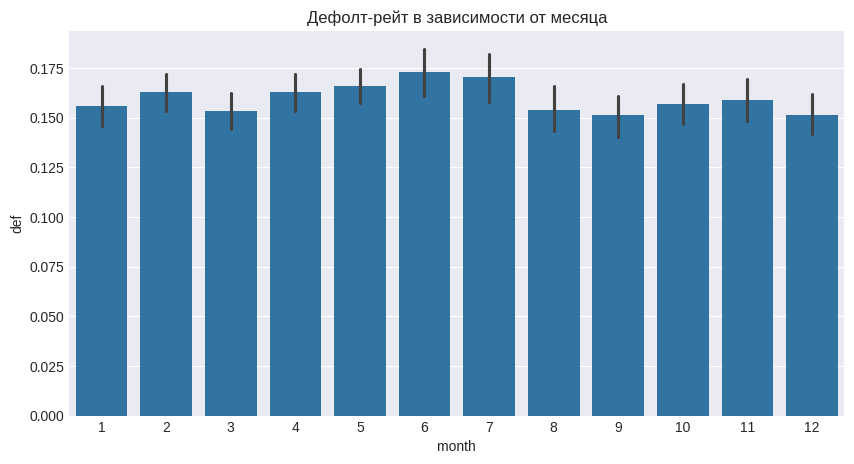

In [216]:
train['day_of_week'] = train['issue_d'].dt.dayofweek
train['month'] = train['issue_d'].dt.month

plt.figure(figsize=(10,5))
sns.barplot(x='day_of_week', y='def', data=train)
plt.title('Дефолт-рейт в зависимости от дня недели')
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='month', y='def', data=train)
plt.title('Дефолт-рейт в зависимости от месяца')
plt.show()

### 11. Описательные статистики числовых признаков

In [217]:
print("Описательные статистики:\n")
print(train.describe())

Описательные статистики:

                             issue_d   installment           dti  \
count                          61169  61169.000000  61169.000000   
mean   2013-04-18 18:39:09.307655936    432.671268     16.782808   
min              2010-04-01 00:00:00      4.930000      0.000000   
25%              2012-11-01 00:00:00    257.540000     11.180000   
50%              2013-08-01 00:00:00    382.490000     16.500000   
75%              2014-01-01 00:00:00    565.310000     22.200000   
max              2014-05-01 00:00:00   1408.130000     34.990000   
std                              NaN    243.699189      7.531950   

        funded_amnt    annual_inc    emp_length          term  inq_last_6mths  \
count  61169.000000  6.116900e+04  58495.000000  61169.000000    61169.000000   
mean   14159.664618  7.271755e+04      6.025284     42.276120        0.831254   
min     1000.000000  6.695000e+03      0.000000     36.000000        0.000000   
25%     8000.000000  4.500000e+04    

### 12. Корреляция между числовыми признаками

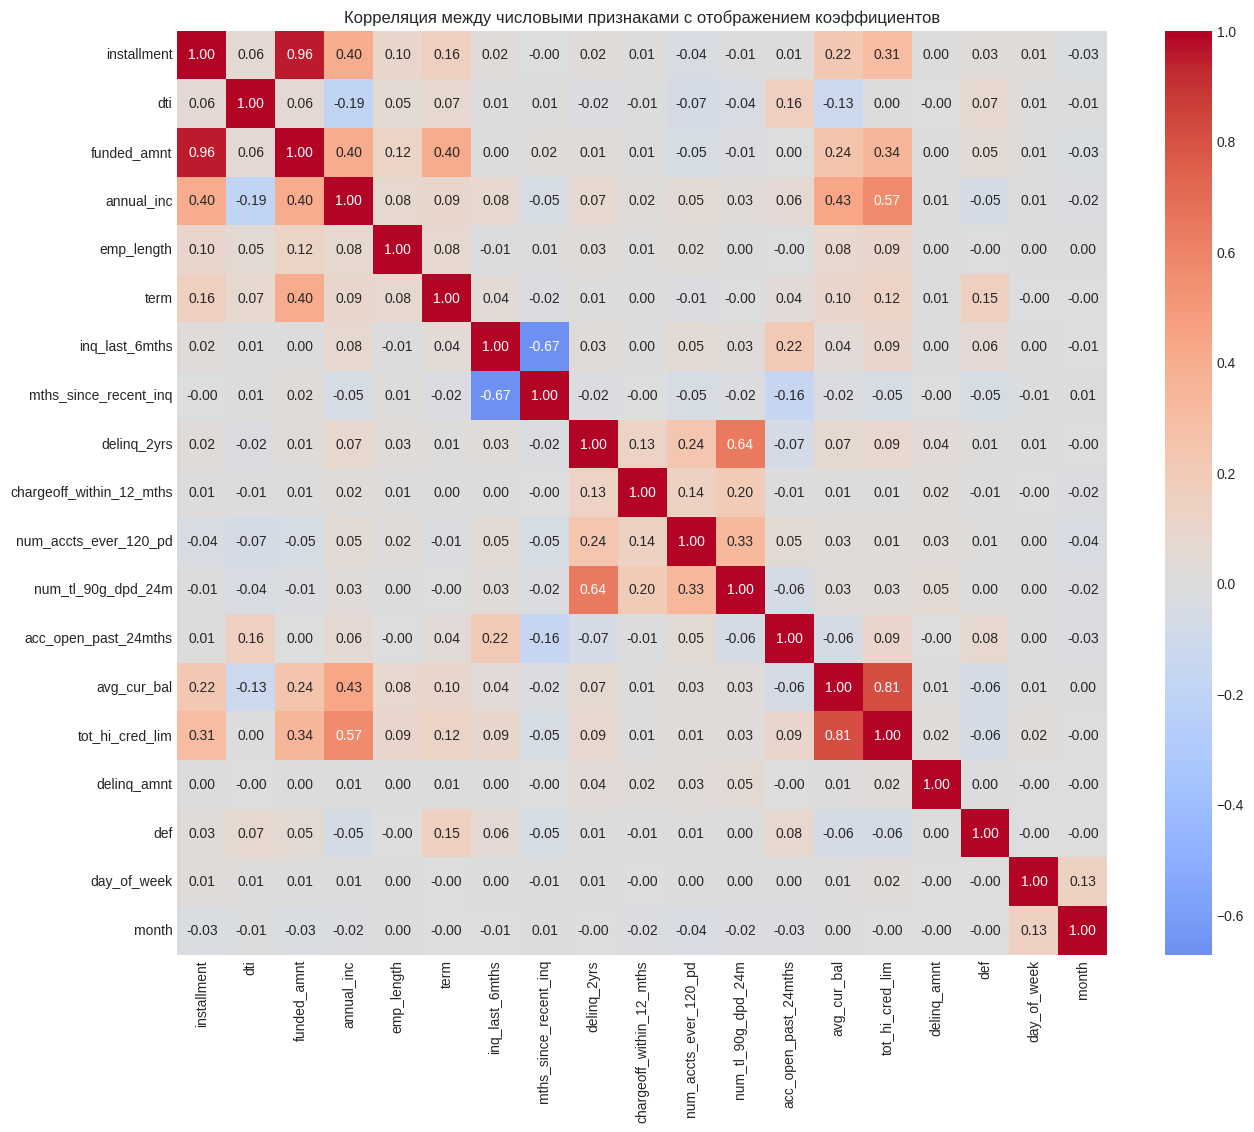

In [218]:
numerical_features = train.select_dtypes(include=[np.number])
corr = numerical_features.corr()

plt.figure(figsize=(15,12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Корреляция между числовыми признаками с отображением коэффициентов')
plt.show()

### 13. Распределение основных признаков в зависимости от дефолта

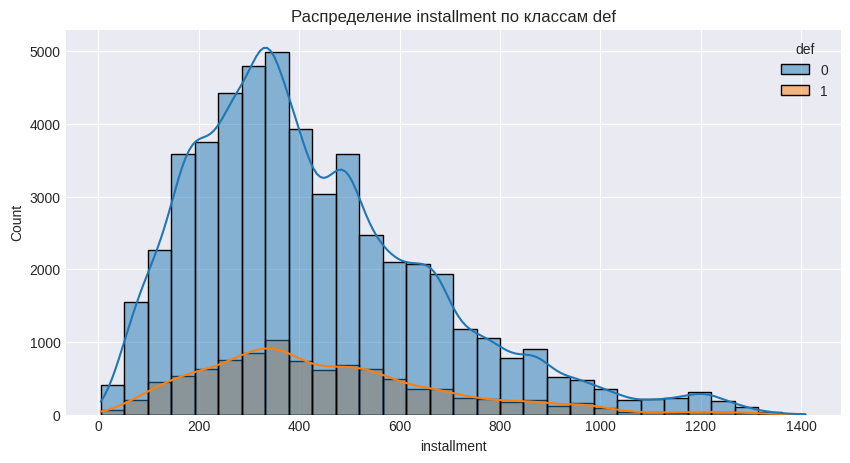

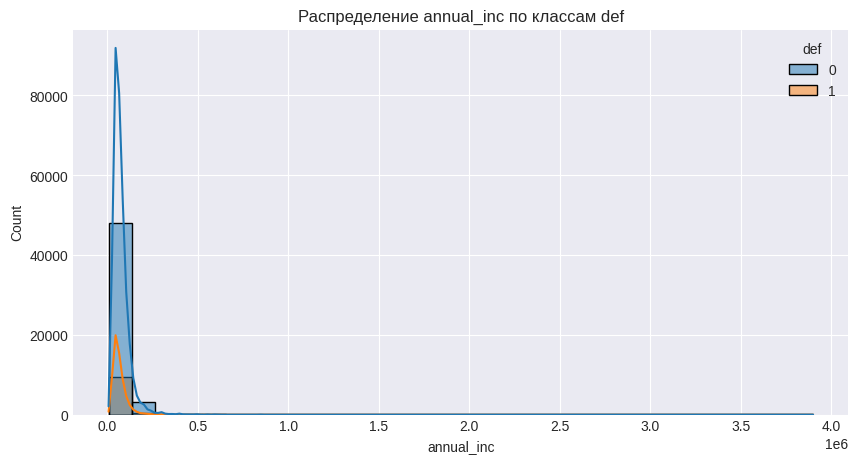

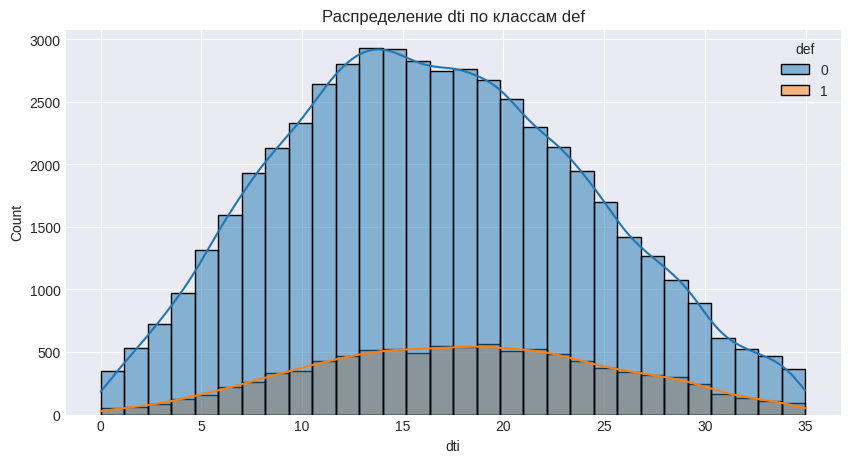

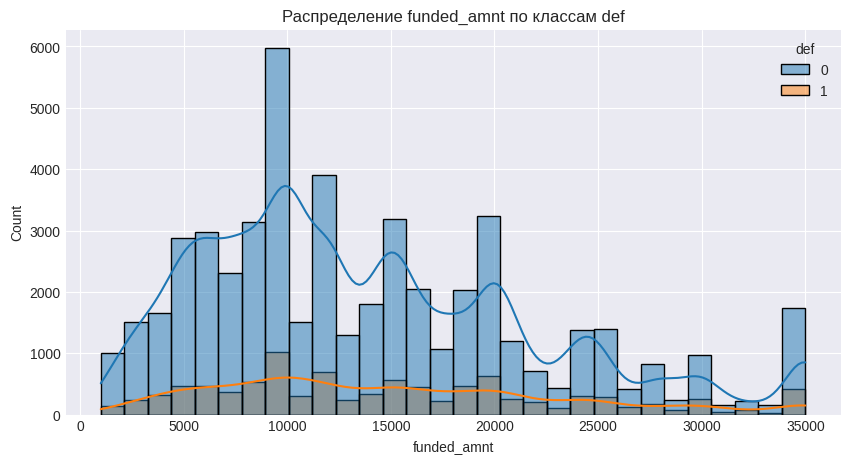

In [219]:
features_to_plot = ['installment', 'annual_inc', 'dti', 'funded_amnt']

for feature in features_to_plot:
    plt.figure(figsize=(10,5))
    sns.histplot(data=train, x=feature, hue='def', kde=True, bins=30)
    plt.title(f'Распределение {feature} по классам def')
    plt.show()

### 14. Анализ выбросов через boxplot

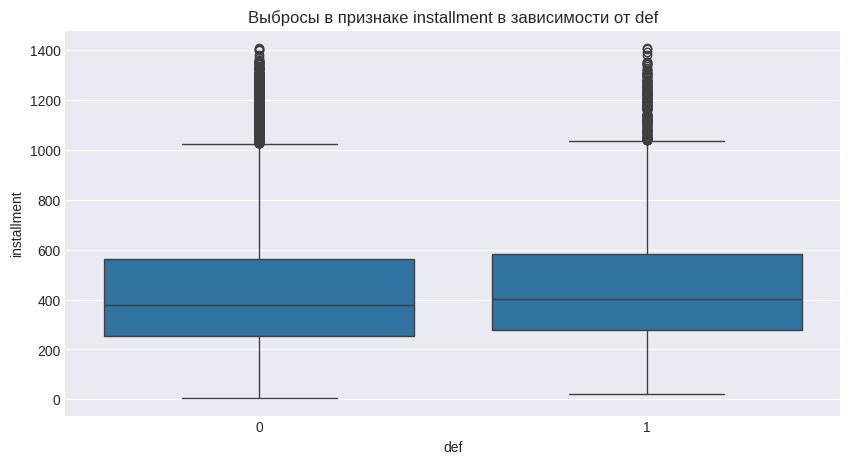

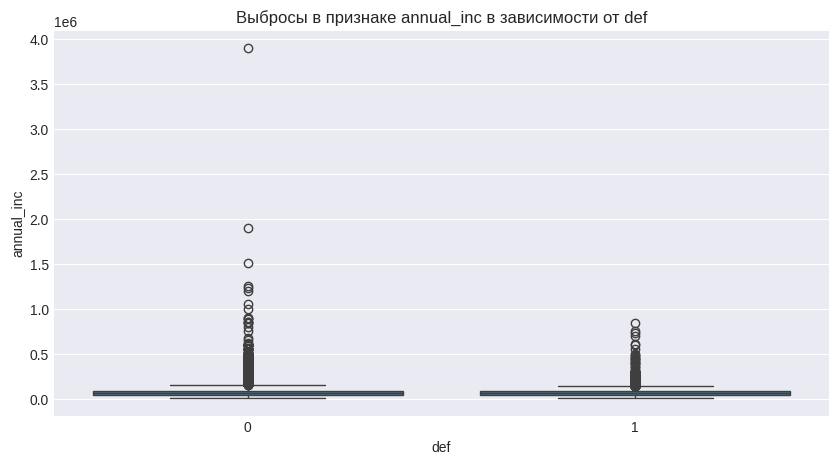

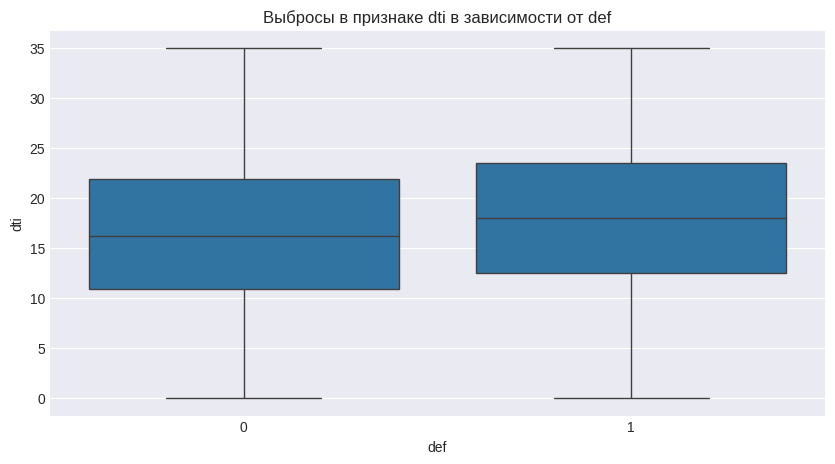

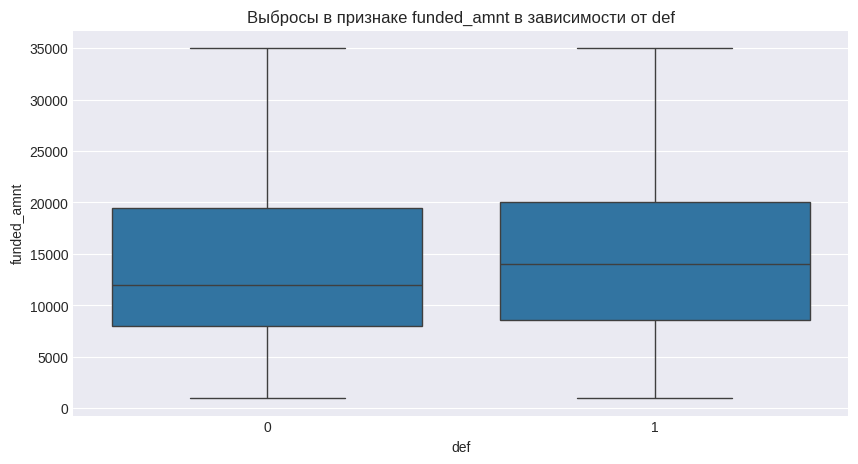

In [220]:
for feature in features_to_plot:
    plt.figure(figsize=(10,5))
    sns.boxplot(x='def', y=feature, data=train)
    plt.title(f'Выбросы в признаке {feature} в зависимости от def')
    plt.show()

### 15. (Доп) Расчёт Information Value (IV) для отбора признаков

Предварительный отбор признаков на основе их информативности.

In [221]:
def calc_iv(df, feature, target):
    lst = []
    eps = 1e-6
    for val in df[feature].unique():
        total = len(df[df[feature] == val])
        events = len(df[(df[feature] == val) & (df[target] == 1)])
        non_events = total - events
        lst.append({'Value': val, 'Total': total, 'Events': events, 'Non_Events': non_events})
    iv_df = pd.DataFrame(lst)
    iv_df['Event_Rate'] = iv_df['Events'] / (iv_df['Total'] + eps)
    iv_df['Non_Event_Rate'] = iv_df['Non_Events'] / (iv_df['Total'] + eps)
    iv_df['Distribution_Event'] = iv_df['Events'] / (iv_df['Events'].sum() + eps)
    iv_df['Distribution_Non_Event'] = iv_df['Non_Events'] / (iv_df['Non_Events'].sum() + eps)
    iv_df['WOE'] = np.log((iv_df['Distribution_Event'] + eps) / (iv_df['Distribution_Non_Event'] + eps))
    iv_df['IV'] = (iv_df['Distribution_Event'] - iv_df['Distribution_Non_Event']) * iv_df['WOE']
    return iv_df['IV'].sum()

iv_values = {}

for col in train.columns:
    if train[col].nunique() < 20 and col not in ['def', 'issue_d', 'issue_month', 'day_of_week', 'month']:
        iv = calc_iv(train, col, 'def')
        iv_values[col] = iv

iv_sorted = pd.Series(iv_values).sort_values(ascending=False)

print("Information Value по признакам:\n")
print(iv_sorted)

Information Value по признакам:

term                        0.158134
inq_last_6mths              0.030371
purpose                     0.029756
home_ownership              0.013706
delinq_2yrs                 0.005549
num_accts_ever_120_pd       0.005480
num_tl_90g_dpd_24m          0.004277
emp_length                  0.001659
chargeoff_within_12_mths    0.000720
dtype: float64


### Анализ результатов EDA

#### Распределение целевой переменной
- Доля дефолтов в обучающей выборке составляет примерно **15.96%**, недефолтов — **84.04%**.
- Таким образом, выборка **несбалансированная** (но уровень несбалансированности умеренный и допустимый для моделирования).

#### Пропуски в данных
- Пропуски присутствуют в ряде признаков, наиболее значимые:
  - `mths_since_recent_inq` — пропуски в **22.1%** записей.
  - `avg_cur_bal`, `num_tl_90g_dpd_24m`, `num_accts_ever_120_pd`, `tot_hi_cred_lim` — пропуски в **~19.5%**.
  - `emp_title` и `emp_length` также имеют пропуски, но в меньшем объеме.
- Требуется аккуратная обработка пропусков: либо заполнение, либо исключение признаков с высоким процентом пропусков.

#### Распределение наблюдений по месяцам
- Количество заявок постепенно увеличивается от 2010 до 2014 года.
- Явных провалов по месяцам не наблюдается — **репрезентативность по времени сохранена**.
- Выборку можно использовать полностью без удаления месяцев.

#### Информативность признаков (IV-анализ)
- Признаки с высоким IV (>0.1), рекомендованные к использованию:
  - `term` (IV ≈ 0.158) — очень сильный предиктор дефолта.
- Признаки со средним IV (0.02–0.1), возможно полезные:
  - `inq_last_6mths` (IV ≈ 0.03)
  - `purpose` (IV ≈ 0.03)
- Признаки с низким IV (<0.02):
  - `home_ownership`, `delinq_2yrs`, `num_accts_ever_120_pd`, `num_tl_90g_dpd_24m`, `emp_length`, `chargeoff_within_12_mths` — могут иметь ограниченную пользу для модели.
  
(Возможно после допполнительной обработка/инжиниринга признаков другие признаки тоже будут полезны)

#### Корреляция признаков с таргетом
- Наибольшую положительную корреляцию с дефолтом имеют:
  - `term` (0.1535) — чем больше срок кредита, тем выше вероятность дефолта.
  - `acc_open_past_24mths` (0.0785), `dti` (0.0744), `inq_last_6mths` (0.0614).
- Отрицательная слабая корреляция у признаков дохода и лимитов:
  - `annual_inc`, `avg_cur_bal`, `tot_hi_cred_lim` — чем выше доходы и лимиты, тем ниже вероятность дефолта.

#### Выводы по EDA
- Выборка подходит для моделирования без существенных корректировок по времени.
- Требуется аккуратная обработка пропущенных данных.
- `term`, `inq_last_6mths`, `purpose` — наиболее перспективные признаки по IV и корреляции.
- Возможны дополнительные улучшения модели через создание новых признаков и WOE-трансформацию существующих.


# 2. Подготовка данных


На данном этапе проведём базовую обработку данных:

- Обработка пропусков.
- Приведение типов признаков.
- Первичный отбор признаков.
- Разделение выборки на обучающую (Train) и отложенную (OOS) части для последующего построения модели и подбора гиперпараметров.

### 1. Обработка пропусков


В нашем случае:

- Пропуски наблюдаются в признаках, связанных с кредитной активностью (`mths_since_recent_inq`, `avg_cur_bal`, `tot_hi_cred_lim` и др.).
- Пропуски также есть в анкетных данных (`emp_title`, `emp_length`).
- Это соответствует типам **MAR** и **MNAR**.

**Соответственно:**

- Удалять записей с пропусками нельзя.
- Пропуски заполняются специальными значениями, чтобы сохранить факт отсутствия данных для модели.

**Определение признаков для обработки**

Анализ пропусков показал следующие признаки с пропущенными значениями:

- `mths_since_recent_inq` (22.1%) — числовой, пропуски заполняются -1.
- `avg_cur_bal` (19.5%) — числовой, пропуски заполняются -1.
- `num_tl_90g_dpd_24m` (19.5%) — числовой, пропуски заполняются -1.
- `num_accts_ever_120_pd` (19.5%) — числовой, пропуски заполняются -1.
- `tot_hi_cred_lim` (19.5%) — числовой, пропуски заполняются -1.
- `acc_open_past_24mths` (12.9%) — числовой, пропуски заполняются -1.
- `emp_title` (6.3%) — категориальный, пропуски заполняются `'Unknown'`.
- `emp_length` (4.4%) — числовой, пропуски заполняются -1.

Другие признаки пропусков не имеют.

In [222]:
# Заполнение пропусков в числовых признаках

num_cols_with_nans = [
    'mths_since_recent_inq',
    'avg_cur_bal',
    'num_tl_90g_dpd_24m',
    'num_accts_ever_120_pd',
    'tot_hi_cred_lim',
    'acc_open_past_24mths'
]

for col in num_cols_with_nans:
    if col in train.columns:
        train[col] = train[col].fillna(-1)

# Заполнение пропусков в категориальных признаках
if 'emp_title' in train.columns:
    train['emp_title'] = train['emp_title'].fillna('Unknown')
if 'emp_length' in train.columns:
    train['emp_length'] = train['emp_length'].fillna(-1)

train['issue_d'] = pd.to_datetime(train['issue_d'])

**Примечание:**

Использование специального значения (-1 или 'Unknown') позволяет сохранить информацию о наличии пропуска.  
Это важно, поскольку сам факт отсутствия информации может коррелировать с риском дефолта.


### 2. Приведение типов признаков

In [223]:
numeric_features_full = [
    'installment', 'dti', 'funded_amnt', 'annual_inc',
    'inq_last_6mths', 'mths_since_recent_inq', 'acc_open_past_24mths',
    'avg_cur_bal', 'tot_hi_cred_lim', 'delinq_amnt'
]

for col in numeric_features_full:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors='coerce')
        train[col] = train[col].fillna(-1)

### 3. Первичный отбор признаков

На данном этапе проводится первичная очистка пространства признаков:
- Удаление признаков с низкой предсказательной способностью по метрике Information Value (IV < 0.02).

Цель первичного отбора:
- Исключить бесполезные признаки, которые не несут дополнительной информации для модели.
- Повысить интерпретируемость и устойчивость итоговой модели.

**Важно:**

Признаки с низким IV (< 0.02) на данном этапе удаляются,  
так как они имеют очень слабую связь с целевой переменной.  
Однако в дальнейшем процессе построения модели можно рассмотреть генерацию новых признаков на основе этих полей

In [224]:
# 1. Отбор по IV
iv_threshold = 0.02

important_iv_features = iv_sorted[iv_sorted >= iv_threshold].index.tolist()

print("\nПризнаки с IV >= 0.02:")
print(important_iv_features)

# Исключение признаков с низким IV
cols_to_drop_by_iv = [col for col in iv_sorted.index if col not in important_iv_features]
print(f"Признаки с низким IV (< {iv_threshold}): {cols_to_drop_by_iv}")

train = train.drop(columns=cols_to_drop_by_iv, errors='ignore')

print(f"Удалено {len(cols_to_drop_by_iv)} признаков с низким IV.")

# 2. Теперь дополнительно УБИРАЕМ вручную delinq_amnt
if 'delinq_amnt' in train.columns:
    train = train.drop(columns=['delinq_amnt'])
    print("\nУдалён признак 'delinq_amnt' из-за низкой вариативности.")

# 3. Список оставшихся признаков
print("\nСписок признаков после первичного отбора:")
remaining_features = train.columns.tolist()
print(remaining_features)
print(f"Итого осталось признаков: {len(remaining_features)}")

# 4. Обновлённые списки категориальных и числовых признаков
categorical_features = ['purpose', 'addr_state', 'sub_grade', 'term']
numeric_features = [
    'installment', 'dti', 'funded_amnt', 'annual_inc',
    'inq_last_6mths', 'mths_since_recent_inq', 'acc_open_past_24mths',
    'avg_cur_bal', 'tot_hi_cred_lim'
]



Признаки с IV >= 0.02:
['term', 'inq_last_6mths', 'purpose']
Признаки с низким IV (< 0.02): ['home_ownership', 'delinq_2yrs', 'num_accts_ever_120_pd', 'num_tl_90g_dpd_24m', 'emp_length', 'chargeoff_within_12_mths']
Удалено 6 признаков с низким IV.

Удалён признак 'delinq_amnt' из-за низкой вариативности.

Список признаков после первичного отбора:
['issue_d', 'purpose', 'addr_state', 'sub_grade', 'emp_title', 'installment', 'dti', 'funded_amnt', 'annual_inc', 'term', 'inq_last_6mths', 'mths_since_recent_inq', 'acc_open_past_24mths', 'avg_cur_bal', 'tot_hi_cred_lim', 'def', 'issue_month', 'day_of_week', 'month']
Итого осталось признаков: 19


### 4. Разделение обучающей выборки на Train и OOS

In [225]:
from sklearn.model_selection import train_test_split

X_full = train[categorical_features + numeric_features]
y_full = train['def']
X_train, X_oos, y_train, y_oos = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

print(f"Размер обучающей выборки (Train): {X_train.shape}")
print(f"Размер отложенной выборки (OOS): {X_oos.shape}")

Размер обучающей выборки (Train): (42818, 13)
Размер отложенной выборки (OOS): (18351, 13)


# 3. Построение интерпретируемого скоринга

## 3a. Генерация новый признаков

На данном этапе проводится создание новых производных признаков на основе исходных данных.
Цель генерации признаков — улучшить качество модели за счёт дополнительной информации.

In [226]:
import numpy as np

# Отношение суммы займа к годовому доходу
train['loan_to_income'] = train['funded_amnt'] / (train['annual_inc'] + 1)

# Логарифм годового дохода
train['log_annual_inc'] = np.log(train['annual_inc'] + 1)

# Отношение ежемесячного платежа к месячному доходу
train['installment_to_income'] = train['installment'] / ((train['annual_inc'] / 12) + 1)

# Проверка генерации
print(train[['loan_to_income', 'log_annual_inc', 'installment_to_income']].head())
numeric_features += ['loan_to_income', 'log_annual_inc', 'installment_to_income']

   loan_to_income  log_annual_inc  installment_to_income
0        0.231471        9.980495               0.095769
1        0.210524       11.461643               0.085245
2        0.266664       11.407576               0.107884
3        0.232553       10.668979               0.095571
4        0.209674       11.034906               0.091643


## 3b. Построение WOE-преобразований для всех признаков

На данном этапе проводится построение WOE-преобразований для всех категориальных и числовых признаков.
Цель WOE-преобразования — повысить интерпретируемость модели и стабилизировать влияние признаков.


In [227]:
# Базовая функция для расчета WOE и IV
def calculate_woe_iv(df, feature, target):
    eps = 1e-6  # Защита от деления на ноль
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped['non_event'] = grouped['count'] - grouped['sum']
    grouped['event_rate'] = grouped['sum'] / (grouped['sum'].sum() + eps)
    grouped['non_event_rate'] = grouped['non_event'] / (grouped['non_event'].sum() + eps)
    grouped['woe'] = np.log((grouped['event_rate'] + eps) / (grouped['non_event_rate'] + eps))
    grouped['iv'] = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['woe']
    return grouped['woe'].to_dict(), grouped['iv'].sum()

# Создаем копию данных для работы
train_woe = train.copy()

# Словарь для сохранения WOE и IV
woe_info = {}

# WOE для категориальных признаков
for feature in categorical_features:
    woe_mapping, iv = calculate_woe_iv(train_woe, feature, 'def')
    woe_info[feature] = {'IV': iv, 'WOE': woe_mapping}
    train_woe[feature] = train_woe[feature].map(woe_mapping)

# Биннинг числовых признаков + WOE
bin_count = 5

for feature in numeric_features:
    bins = np.percentile(train_woe[feature], np.linspace(0, 100, bin_count + 1))
    bins = np.unique(bins)
    train_woe[feature + '_bin'] = pd.cut(train_woe[feature], bins=bins, duplicates='drop')

    woe_mapping, iv = calculate_woe_iv(train_woe, feature + '_bin', 'def')
    woe_info[feature] = {'IV': iv, 'WOE': woe_mapping}

    train_woe[feature] = train_woe[feature + '_bin'].map(woe_mapping)

# Удаляем временные колонки с биннингами
train_woe = train_woe.drop(columns=[col for col in train_woe.columns if '_bin' in col])

print("WOE-преобразование признаков завершено.")

WOE-преобразование признаков завершено.


In [228]:
# 1. Приведение всех признаков к типу float
for col in categorical_features + numeric_features:
    train_woe[col] = pd.to_numeric(train_woe[col], errors='coerce')

# 2. Заполнение пропусков нулями
train_woe[categorical_features + numeric_features] = train_woe[categorical_features + numeric_features].fillna(0)

print("Все пропуски заполнены, типы данных приведены к float64.")

Все пропуски заполнены, типы данных приведены к float64.


### Проверка

In [229]:
# 1. Проверка пропусков после WOE
missing_after_woe = train_woe[categorical_features + numeric_features].isnull().sum()
print("Пропуски после WOE-преобразования:")
print(missing_after_woe)

# 2. Проверка типов признаков
types_after_woe = train_woe[categorical_features + numeric_features].dtypes
print("\nТипы данных после WOE-преобразования:")
print(types_after_woe)

# 3. Примеры значений после WOE
print("\nПримеры значений после WOE-преобразования:")
print(train_woe[categorical_features + numeric_features].head())

# 4. Проверка размерности
print(f"\nРазмерность train_woe после WOE-преобразования: {train_woe.shape}")

Пропуски после WOE-преобразования:
purpose                  0
addr_state               0
sub_grade                0
term                     0
installment              0
dti                      0
funded_amnt              0
annual_inc               0
inq_last_6mths           0
mths_since_recent_inq    0
acc_open_past_24mths     0
avg_cur_bal              0
tot_hi_cred_lim          0
loan_to_income           0
log_annual_inc           0
installment_to_income    0
dtype: int64

Типы данных после WOE-преобразования:
purpose                  float64
addr_state               float64
sub_grade                float64
term                     float64
installment              float64
dti                      float64
funded_amnt              float64
annual_inc               float64
inq_last_6mths           float64
mths_since_recent_inq    float64
acc_open_past_24mths     float64
avg_cur_bal              float64
tot_hi_cred_lim          float64
loan_to_income           float64
log_annual_inc     

## 3c. Отбор признаков для анализа после WOE-преобразования

На данном этапе проводится финальный отбор признаков:
- Удаляются признаки с низкой вариативностью,
- Формируется окончательный список признаков для построения интерпретируемой модели.

**!!!: тут был найден признак `delinq_amnt` он был убран до**

In [230]:
# Проверка на почти константные признаки
low_variability_features = []

for col in categorical_features + numeric_features:
    top_freq = train_woe[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        low_variability_features.append(col)

print(f"Признаки с низкой вариативностью (>95% одного значения): {low_variability_features}")
# Исключение таких признаков
selected_features = [col for col in categorical_features + numeric_features if col not in low_variability_features]

print(f"\nФинальный список признаков для логистической регрессии:")
print(selected_features)
print(f"Итого признаков: {len(selected_features)}")


Признаки с низкой вариативностью (>95% одного значения): []

Финальный список признаков для логистической регрессии:
['purpose', 'addr_state', 'sub_grade', 'term', 'installment', 'dti', 'funded_amnt', 'annual_inc', 'inq_last_6mths', 'mths_since_recent_inq', 'acc_open_past_24mths', 'avg_cur_bal', 'tot_hi_cred_lim', 'loan_to_income', 'log_annual_inc', 'installment_to_income']
Итого признаков: 16


**Вывод:**

- Признак `delinq_amnt` удалён из-за низкой вариативности (>95% одного значения).
- Сформирован финальный список из 13 признаков для построения логистической регрессии.

## 3d. Подбор оптимального гиперпараметра C через кросс-валидацию

На данном этапе проводится подбор оптимального гиперпараметра регуляризации (C) для логистической регрессии с использованием кросс-валидации на обучающей выборке.
Цель подбора — максимизировать качество модели по метрике ROC-AUC.

In [231]:
# Выбор только нужных признаков из train_woe для Train и OOS
X_train_woe = train_woe.loc[X_train.index, selected_features]
X_oos_woe = train_woe.loc[X_oos.index, selected_features]

print(f"Размерность X_train_woe: {X_train_woe.shape}")
print(f"Размерность X_oos_woe: {X_oos_woe.shape}")

Размерность X_train_woe: (42818, 16)
Размерность X_oos_woe: (18351, 16)


In [232]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Инициализация модели
logreg = LogisticRegression(solver='liblinear', random_state=42)

# Сетка параметров для подбора
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Кросс-валидация с подбором
grid_search = GridSearchCV(
    logreg,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Обучение на WOE-признаках
grid_search.fit(X_train_woe, y_train)

# Лучший найденный параметр C
best_C = grid_search.best_params_['C']
print(f"Лучший найденный C: {best_C}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучший найденный C: 1


## 3e. Построение финальной логистической регрессии

На данном этапе строится финальная модель логистической регрессии на оптимальном значении гиперпараметра регуляризации (C=1) и проводится её оценка на отложенной выборке (OOS).


In [233]:
from sklearn.metrics import roc_auc_score, roc_curve

# Обучение финальной модели
final_model = LogisticRegression(C=best_C, solver='liblinear', random_state=42)
final_model.fit(X_train_woe, y_train)

print("Финальная модель обучена на Train-наборе.")

Финальная модель обучена на Train-наборе.


ROC-AUC на OOS: 0.6930
Gini на OOS: 0.3860


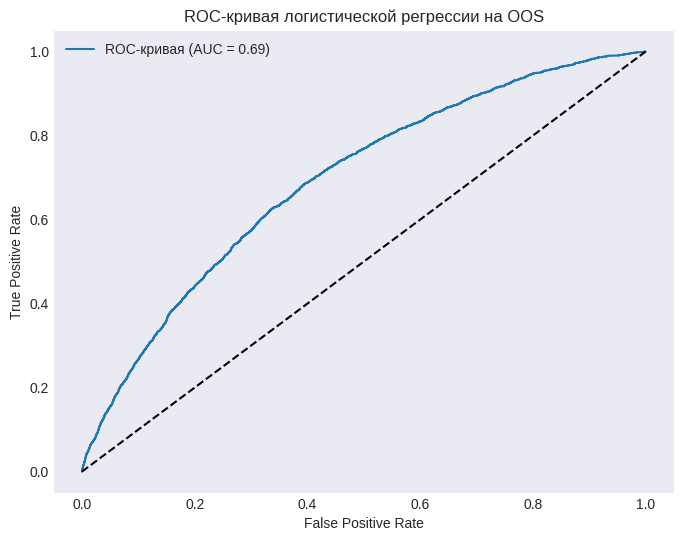

KS-статистика на OOS: 0.2905


In [234]:
# Предсказания вероятностей на OOS
y_oos_pred_proba = final_model.predict_proba(X_oos_woe)[:, 1]

# ROC-AUC и Gini
roc_auc_oos = roc_auc_score(y_oos, y_oos_pred_proba)
gini_oos = 2 * roc_auc_oos - 1

print(f"ROC-AUC на OOS: {roc_auc_oos:.4f}")
print(f"Gini на OOS: {gini_oos:.4f}")

# Построение ROC-кривой
fpr_oos, tpr_oos, thresholds_oos = roc_curve(y_oos, y_oos_pred_proba)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(fpr_oos, tpr_oos, label=f'ROC-кривая (AUC = {roc_auc_oos:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая логистической регрессии на OOS')
plt.legend()
plt.grid()
plt.show()

# KS-статистика
ks_statistic = max(tpr_oos - fpr_oos)
print(f"KS-статистика на OOS: {ks_statistic:.4f}")

**Вывод по финальной логистической регрессии:**

- Модель обучена на оптимальном значении гиперпараметра C=1.
- Качество модели на отложенной выборке (OOS) соответствует ожиданиям для скоринговых моделей:
  - ROC-AUC = 0.6930
  - Gini = 0.3860
  - KS-статистика = 0.2905
- Модель обладает хорошей способностью к ранжированию клиентов по риску дефолта.


# 4. Валидация финальной логистической модели

На данном этапе проводится валидация построенной модели на отложенной выборке с использованием стандартной методологии скоринговой валидации.
Всего проводится 9 тестов.

## Подготовка валидационной выборки

Размер валидационной выборки после удаления пропусков в таргете: (60323, 26)

 Валидация финальной модели на OOT
ROC-AUC            : 0.6629
Gini-коэффициент   : 0.3258
KS-статистика      : 0.2331


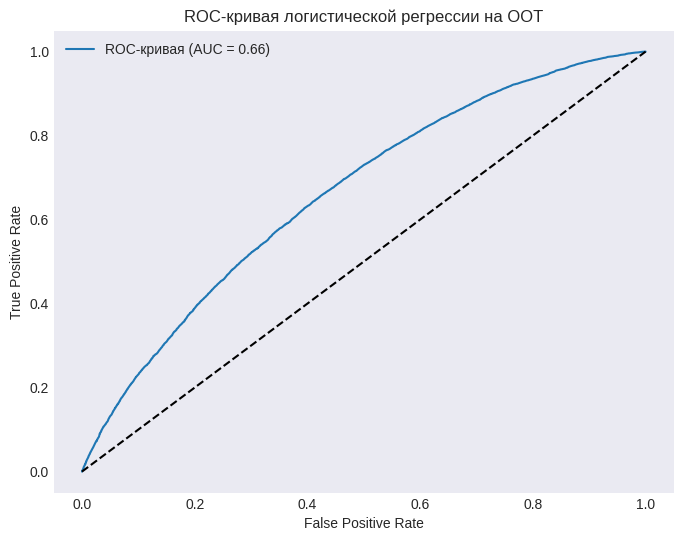

In [235]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

val = pd.read_csv('vl_for_students.csv', encoding='mac_cyrillic', sep=';')
val['issue_d'] = pd.to_datetime(val['issue_d'])

numeric_features_base = [
    'installment', 'dti', 'funded_amnt', 'annual_inc',
    'inq_last_6mths', 'mths_since_recent_inq',
    'acc_open_past_24mths', 'avg_cur_bal', 'tot_hi_cred_lim', 'delinq_amnt'
]

for col in numeric_features_base:
    val[col] = pd.to_numeric(val[col], errors='coerce').fillna(-1)

val['emp_title']  = val.get('emp_title', 'Unknown').fillna('Unknown')
val['emp_length'] = val.get('emp_length', -1).fillna(-1)

val['loan_to_income']        = val['funded_amnt'] / (val['annual_inc'] + 1)
val['log_annual_inc']        = np.log(val['annual_inc'] + 1)
val['installment_to_income'] = val['installment'] / ((val['annual_inc'] / 12) + 1)

categorical_features = ['purpose', 'addr_state', 'sub_grade', 'term']
numeric_features = [
    'installment', 'dti', 'funded_amnt', 'annual_inc',
    'inq_last_6mths', 'mths_since_recent_inq',
    'acc_open_past_24mths', 'avg_cur_bal', 'tot_hi_cred_lim',
    'loan_to_income', 'log_annual_inc', 'installment_to_income'
]

val_woe = val.copy()

for feature in categorical_features:
    if feature in woe_info:
        val_woe[feature] = val_woe[feature].map(woe_info[feature]['WOE'])

bin_count = 5
for feature in numeric_features:
    if feature in woe_info and feature in train_woe.columns:
        bins = np.percentile(train_woe[feature], np.linspace(0, 100, bin_count + 1))
        bins = np.unique(bins)
        val_woe[feature] = pd.cut(val_woe[feature], bins=bins, duplicates='drop').map(woe_info[feature]['WOE'])

val_woe[categorical_features + numeric_features] = val_woe[categorical_features + numeric_features].fillna(0).astype(float)

val_woe = val_woe[~val_woe['def'].isnull()].copy()
print(f"Размер валидационной выборки после удаления пропусков в таргете: {val_woe.shape}")

X_val = val_woe[selected_features]
y_val = val_woe['def']

y_val_pred_proba = final_model.predict_proba(X_val)[:, 1]

roc_auc_val = roc_auc_score(y_val, y_val_pred_proba)
gini_val = 2 * roc_auc_val - 1
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
ks_val = max(tpr_val - fpr_val)

print("\n Валидация финальной модели на OOT")
print(f"ROC-AUC            : {roc_auc_val:.4f}")
print(f"Gini-коэффициент   : {gini_val:.4f}")
print(f"KS-статистика      : {ks_val:.4f}")

plt.figure(figsize=(8,6))
plt.plot(fpr_val, tpr_val, label=f'ROC-кривая (AUC = {roc_auc_val:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая логистической регрессии на OOT')
plt.legend()
plt.grid()
plt.show()


## Тест M2.1: Эффективность ранжирования всей модели

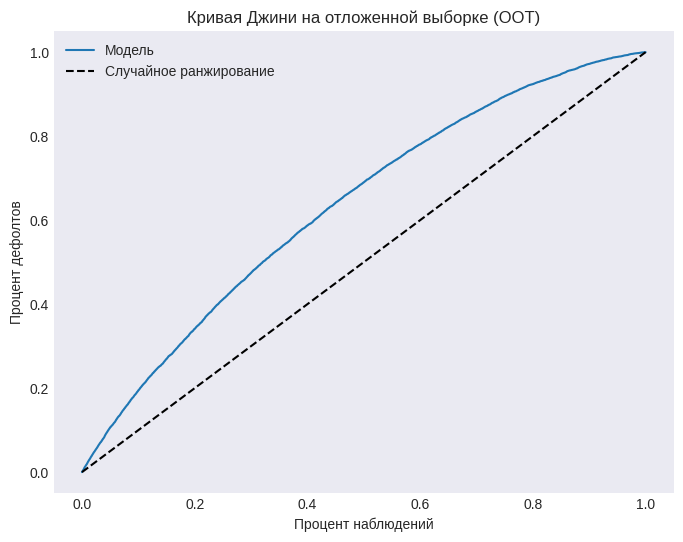


Тест M2.1: Качество ранжирования на OOT
ROC-AUC: 0.6629
Gini   : 0.3258
Итоговая оценка теста M2.1: 🟡 Жёлтый (25%-35%)


In [236]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

oos_results = pd.DataFrame({
    'y_true': y_val.values,
    'y_pred_proba': y_val_pred_proba,
    'issue_d': val_woe.loc[y_val.index, 'issue_d'].values
}).sort_values('y_pred_proba', ascending=False).reset_index(drop=True)

oos_results['cum_obs_pct'] = np.linspace(0, 1, len(oos_results))
oos_results['cum_bad_pct'] = oos_results['y_true'].cumsum() / oos_results['y_true'].sum()

plt.figure(figsize=(8,6))
plt.plot(oos_results['cum_obs_pct'], oos_results['cum_bad_pct'], label='Модель')
plt.plot([0,1], [0,1], 'k--', label='Случайное ранжирование')
plt.xlabel('Процент наблюдений')
plt.ylabel('Процент дефолтов')
plt.title('Кривая Джини на отложенной выборке (OOT)')
plt.legend(); plt.grid(); plt.show()

roc_auc_oos = roc_auc_score(oos_results['y_true'], oos_results['y_pred_proba'])
gini_oos = 2 * roc_auc_oos - 1

print(f"\nТест M2.1: Качество ранжирования на OOT")
print(f"ROC-AUC: {roc_auc_oos:.4f}")
print(f"Gini   : {gini_oos:.4f}")

if gini_oos < 0.25:
    color = "🔴 Красный (до 25%)"
elif gini_oos < 0.35:
    color = "🟡 Жёлтый (25%-35%)"
else:
    color = "🟢 Зелёный (35% и выше)"

print(f"Итоговая оценка теста M2.1: {color}")

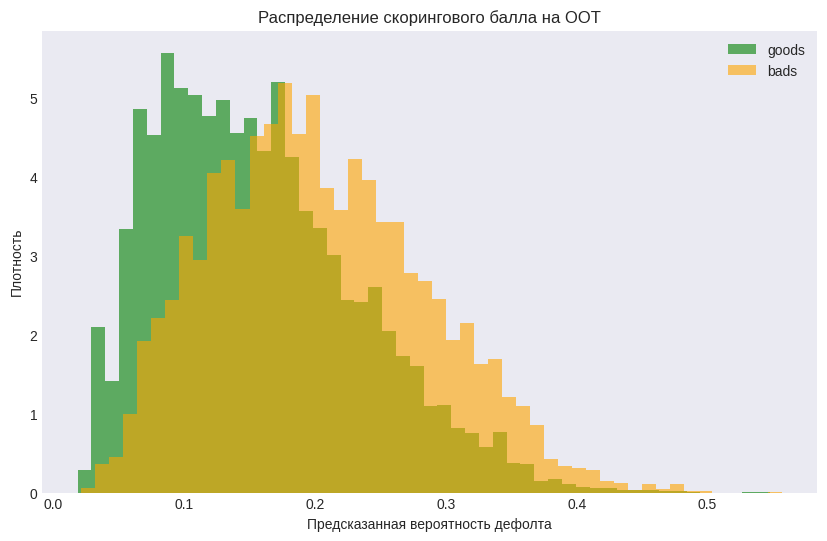

In [237]:
oos_results['good_bad'] = np.where(oos_results['y_true'] == 1, 'bads', 'goods')

plt.figure(figsize=(10,6))

plt.hist(
    oos_results[oos_results['good_bad'] == 'goods']['y_pred_proba'],
    bins=50, density=True, alpha=0.6, label='goods', color='green'
)

plt.hist(
    oos_results[oos_results['good_bad'] == 'bads']['y_pred_proba'],
    bins=50, density=True, alpha=0.6, label='bads', color='orange'
)

plt.title('Распределение скорингового балла на OOT')
plt.xlabel('Предсказанная вероятность дефолта')
plt.ylabel('Плотность')
plt.legend()
plt.grid()
plt.show()

## Тест M2.2 Эффективность ранжирования отдельных факторов


 Коэффициенты Джини по отдельным признакам на OOT


,Feature,Gini,Color
0,sub_grade,0.344126,🟢 Зелёный
1,term,0.124954,🟢 Зелёный
2,purpose,0.061022,🟢 Зелёный
3,addr_state,0.034332,🟡 Жёлтый
4,installment,0.000000,🟡 Жёлтый
5,dti,0.000000,🟡 Жёлтый
6,funded_amnt,0.000000,🟡 Жёлтый
7,annual_inc,0.000000,🟡 Жёлтый
8,inq_last_6mths,0.000000,🟡 Жёлтый
9,mths_since_recent_inq,0.000000,🟡 Жёлтый


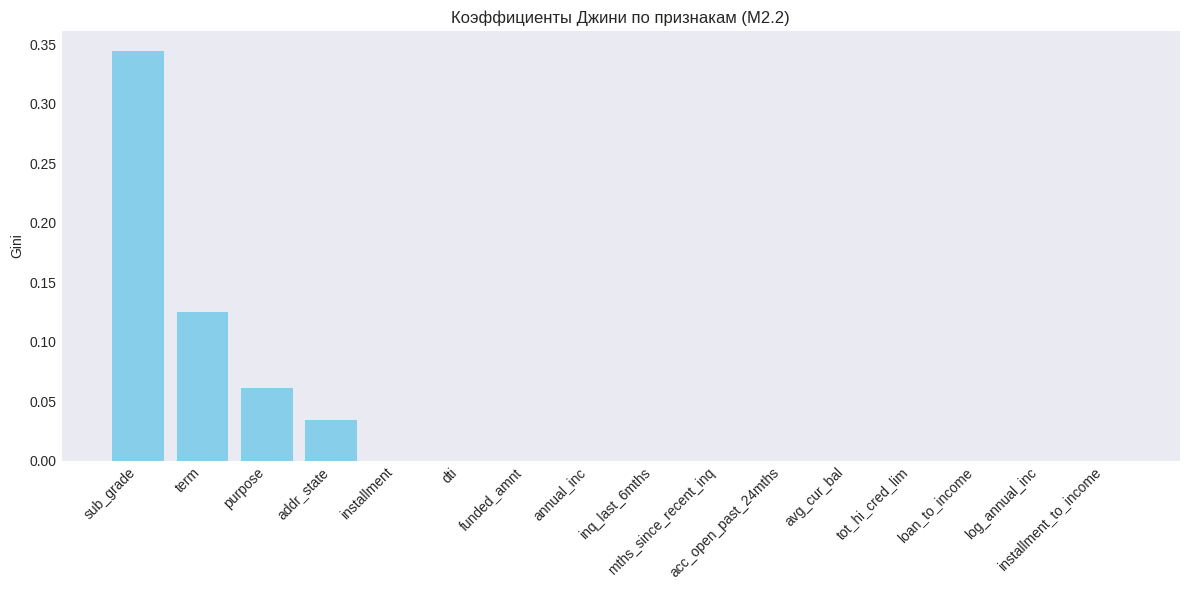

🔴 Красных факторов: 0
🟡 Жёлтых факторов : 13
🟢 Зелёных факторов: 3

Итоговая оценка теста M2.2: 🟡 Жёлтый


In [238]:
from sklearn.metrics import roc_auc_score
gini_by_feature = {}

for feature in X_val.columns:
    try:
        auc = roc_auc_score(y_val, X_val[feature])
        gini = 2 * auc - 1
        gini_by_feature[feature] = gini
    except Exception as e:
        print(f"Ошибка при обработке признака {feature}: {e}")

gini_df = pd.DataFrame.from_dict(gini_by_feature, orient='index', columns=['Gini']).sort_values(by='Gini', ascending=False)
gini_df.index.name = 'Feature'
gini_df.reset_index(inplace=True)

def assign_color(g):
    if g < 0:
        return '🔴 Красный'
    elif g <= 0.05:
        return '🟡 Жёлтый'
    else:
        return '🟢 Зелёный'

gini_df['Color'] = gini_df['Gini'].apply(assign_color)

print("\n Коэффициенты Джини по отдельным признакам на OOT")
display(gini_df)

plt.figure(figsize=(12,6))
plt.bar(gini_df['Feature'], gini_df['Gini'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Коэффициенты Джини по признакам (M2.2)')
plt.ylabel('Gini')
plt.grid()
plt.tight_layout()
plt.show()

num_red    = (gini_df['Color'] == '🔴 Красный').sum()
num_yellow = (gini_df['Color'] == '🟡 Жёлтый').sum()
num_green  = (gini_df['Color'] == '🟢 Зелёный').sum()

print(f"🔴 Красных факторов: {num_red}")
print(f"🟡 Жёлтых факторов : {num_yellow}")
print(f"🟢 Зелёных факторов: {num_green}")

if num_red > 0:
    final_color = '🔴 Красный'
elif num_yellow / len(gini_df) > 0.1:
    final_color = '🟡 Жёлтый'
else:
    final_color = '🟢 Зелёный'

print(f"\nИтоговая оценка теста M2.2: {final_color}")


## Тест M2.5 Анализ вкладов факторов в формирование Джини модели

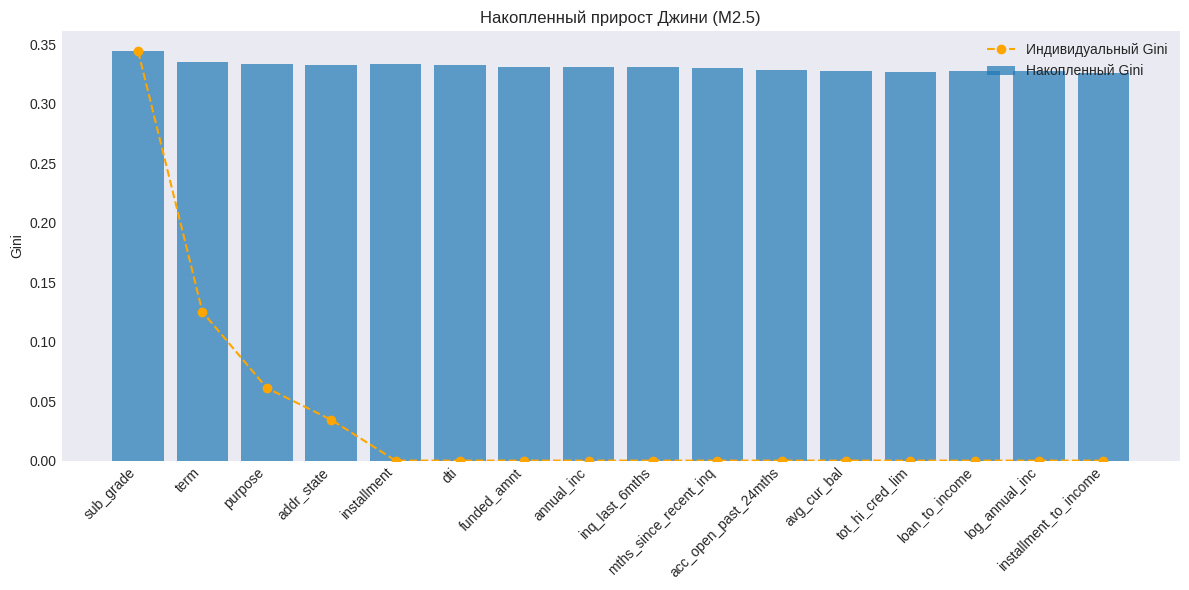

,Feature,Individual_Gini,Cumulative_Gini
0,sub_grade,0.344126,0.344126
1,term,0.124954,0.334929
2,purpose,0.061022,0.333530
3,addr_state,0.034332,0.332807
4,installment,0.000000,0.333282
5,dti,0.000000,0.332611
6,funded_amnt,0.000000,0.330894
7,annual_inc,0.000000,0.331258
8,inq_last_6mths,0.000000,0.331061
9,mths_since_recent_inq,0.000000,0.329768


In [239]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

features_ordered = gini_df.sort_values(by='Gini', ascending=False)['Feature'].tolist()
cumulative_gini = []
individual_gini = []

for i in range(1, len(features_ordered) + 1):
    selected = features_ordered[:i]
    model_temp = LogisticRegression(C=best_C, solver='liblinear', random_state=42, max_iter=1000)
    model_temp.fit(X_train_woe[selected], y_train)
    y_pred = model_temp.predict_proba(X_val[selected])[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    cumulative_gini.append(2 * auc - 1)

individual_gini = gini_df.set_index('Feature').loc[features_ordered, 'Gini'].values

plt.figure(figsize=(12,6))
plt.bar(features_ordered, cumulative_gini, label='Накопленный Gini', alpha=0.7)
plt.plot(features_ordered, individual_gini, marker='o', linestyle='--', color='orange', label='Индивидуальный Gini')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Gini')
plt.title('Накопленный прирост Джини (M2.5)')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

gini_uplift_df = pd.DataFrame({
    'Feature': features_ordered,
    'Individual_Gini': individual_gini,
    'Cumulative_Gini': cumulative_gini
})

display(gini_uplift_df)


## Тест M2.4 Динамика коэффициента Джини по времени

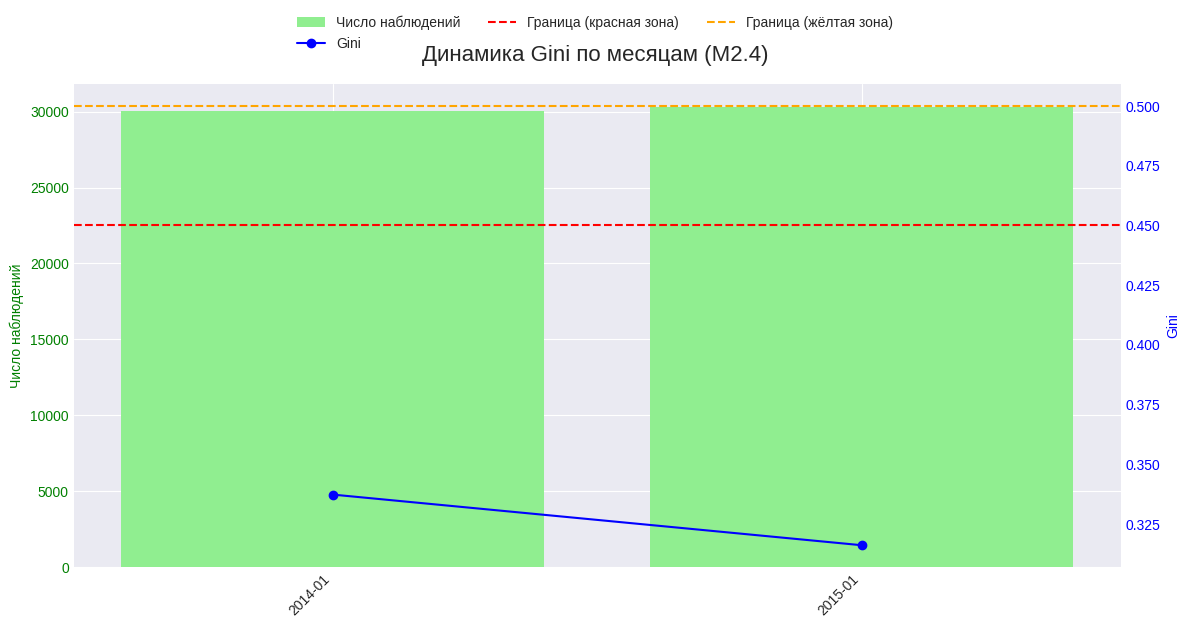


Динамика коэффициента Джини по месяцам


,Month,Gini,Observations
0,2014-01,0.337316,30022
1,2015-01,0.316125,30301


In [240]:
val_woe['issue_month'] = val_woe['issue_d'].dt.to_period('M')

months = sorted(val_woe['issue_month'].unique())

gini_by_month = []
n_obs_by_month = []

for m in months:
    tmp = val_woe[val_woe['issue_month'] == m]
    if len(tmp) >= 30:
        y_true = tmp['def']
        y_pred = final_model.predict_proba(tmp[selected_features])[:, 1]
        auc = roc_auc_score(y_true, y_pred)
        gini = 2 * auc - 1
        gini_by_month.append(gini)
        n_obs_by_month.append(len(tmp))
    else:
        gini_by_month.append(np.nan)
        n_obs_by_month.append(len(tmp))

gini_stability = pd.DataFrame({
    'Month': [str(m) for m in months],
    'Gini': gini_by_month,
    'Observations': n_obs_by_month
}).dropna()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(gini_stability['Month'], gini_stability['Observations'], color='lightgreen', label='Число наблюдений')
ax1.set_ylabel('Число наблюдений', color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xticklabels(gini_stability['Month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(gini_stability['Month'], gini_stability['Gini'], color='blue', marker='o', label='Gini')
ax2.set_ylabel('Gini', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax2.axhline(0.45, color='red', linestyle='--', label='Граница (красная зона)')
ax2.axhline(0.50, color='orange', linestyle='--', label='Граница (жёлтая зона)')

fig.suptitle('Динамика Gini по месяцам (M2.4)', fontsize=16)
fig.tight_layout()
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid()
plt.show()

print("\nДинамика коэффициента Джини по месяцам")
display(gini_stability)


## Тест 3.1 Анализ корректности дискретного преобразования факторов

In [241]:
import warnings
from pandas.api.types import is_numeric_dtype

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

results = []

for feature in selected_features:
    df_temp = val_woe[[feature, 'def']].copy()
    df_temp = df_temp.rename(columns={'def': 'target'})

    if not is_numeric_dtype(df_temp[feature]):
        continue

    try:
        df_temp['bin'] = pd.qcut(df_temp[feature], q=10, duplicates='drop')
        bucket_stats = df_temp.groupby('bin', observed=True)['target'].mean().reset_index()
        bucket_stats['count'] = df_temp.groupby('bin', observed=True)['target'].count().values

        diffs = bucket_stats['target'].diff().abs()
        rel_diffs = diffs / bucket_stats['target'].shift(1)
        rel_diffs = rel_diffs.fillna(0)

        non_monotonic = rel_diffs >= 0.10
        share_non_monotonic = non_monotonic.sum() / len(rel_diffs)

        if share_non_monotonic > 0.1:
            color = '🔴 Красный'
        elif (rel_diffs > 0).sum() > 0:
            color = '🟡 Жёлтый'
        else:
            color = '🟢 Зелёный'

        results.append({
            'Feature': feature,
            'Non_monotonic_changes': int(non_monotonic.sum()),
            'Share_non_monotonic': round(share_non_monotonic, 6),
            'Color': color
        })

    except Exception as e:
        continue

monotonic_df = pd.DataFrame(results).sort_values(by='Share_non_monotonic', ascending=False)

print("Результаты теста M3.1: Проверка монотонности признаков")
display(monotonic_df)

num_red = (monotonic_df['Color'] == '🔴 Красный').sum()
num_yellow = (monotonic_df['Color'] == '🟡 Жёлтый').sum()

if num_red > 0.2 * len(monotonic_df):
    final_color = '🔴 Красный'
elif num_red == 0 and num_yellow > 0.1 * len(monotonic_df):
    final_color = '🟡 Жёлтый'
else:
    final_color = '🟢 Зелёный'

print(f"\nИтоговая оценка теста M3.1: {final_color}")


Результаты теста M3.1: Проверка монотонности признаков


,Feature,Non_monotonic_changes,Share_non_monotonic,Color
2,sub_grade,8,0.80,🔴 Красный
0,purpose,3,0.75,🔴 Красный
1,addr_state,4,0.40,🔴 Красный
3,term,0,0.00,🟢 Зелёный
4,installment,0,NaN,🟢 Зелёный
5,dti,0,NaN,🟢 Зелёный
6,funded_amnt,0,NaN,🟢 Зелёный
7,annual_inc,0,NaN,🟢 Зелёный
8,inq_last_6mths,0,NaN,🟢 Зелёный
9,mths_since_recent_inq,0,NaN,🟢 Зелёный



Итоговая оценка теста M3.1: 🟢 Зелёный


## Тест M4.1 Сравнение прогнозного и фактического TR на уровне выборки

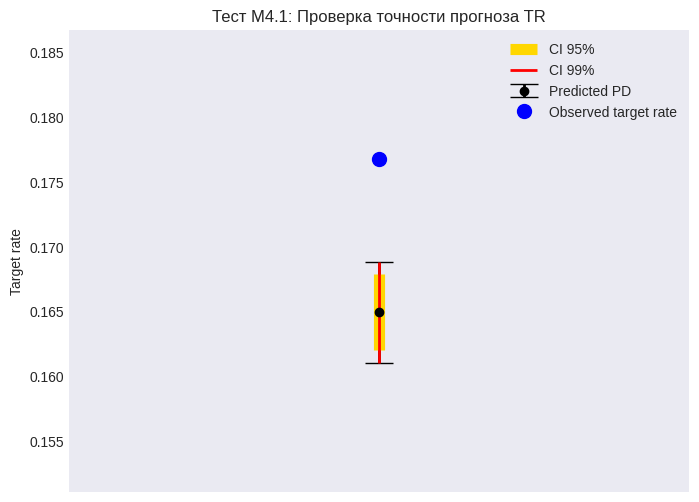


Средний прогноз вероятности дефолта (P): 0.1649
Фактический уровень дефолтов (TR): 0.1767
95% доверительный интервал: (np.float64(0.16197638665622527), np.float64(0.16789969535811317))
99% доверительный интервал: (np.float64(0.16103953681051852), np.float64(0.1688365452038199))
Относительная ошибка: 6.68%
Итог: 🟢 Зелёный (ошибка ≤10%)


In [242]:
import matplotlib.pyplot as plt
from scipy.stats import norm

P = y_val_pred_proba.mean()
TR = y_val.mean()
n = len(y_val_pred_proba)
se = np.sqrt(P * (1 - P) / n)

ci_95 = (P - 1.96 * se, P + 1.96 * se)
ci_99 = (P - 2.58 * se, P + 2.58 * se)

rel_error = abs(TR - P) / TR * 100

plt.figure(figsize=(8, 6))

plt.errorbar(1, P, yerr=[[P - ci_99[0]], [ci_99[1] - P]],
             fmt='o', color='black', capsize=10, label='Predicted PD', lw=2)
plt.errorbar(1, TR, fmt='o', color='blue', label='Observed target rate', markersize=10)

plt.vlines(1, ci_95[0], ci_95[1], colors='gold', lw=8, label='CI 95%')
plt.vlines(1, ci_99[0], ci_99[1], colors='red', lw=2, label='CI 99%')

plt.xlim(0.5, 1.5)
plt.ylim(min(ci_99[0], TR) - 0.01, max(ci_99[1], TR) + 0.01)
plt.ylabel('Target rate')
plt.xticks([])
plt.title('Тест M4.1: Проверка точности прогноза TR')
plt.legend()
plt.grid()
plt.show()

print(f"\nСредний прогноз вероятности дефолта (P): {P:.4f}")
print(f"Фактический уровень дефолтов (TR): {TR:.4f}")
print(f"95% доверительный интервал: {ci_95}")
print(f"99% доверительный интервал: {ci_99}")
print(f"Относительная ошибка: {rel_error:.2f}%")

if rel_error > 20:
    print("Итог: 🔴 Красный (ошибка > 20%)")
elif rel_error > 10:
    print("Итог: 🟡 Жёлтый (ошибка 10%-20%)")
else:
    print("Итог: 🟢 Зелёный (ошибка ≤10%)")


## Тест M4.2 Тест формы калибровочной кривой

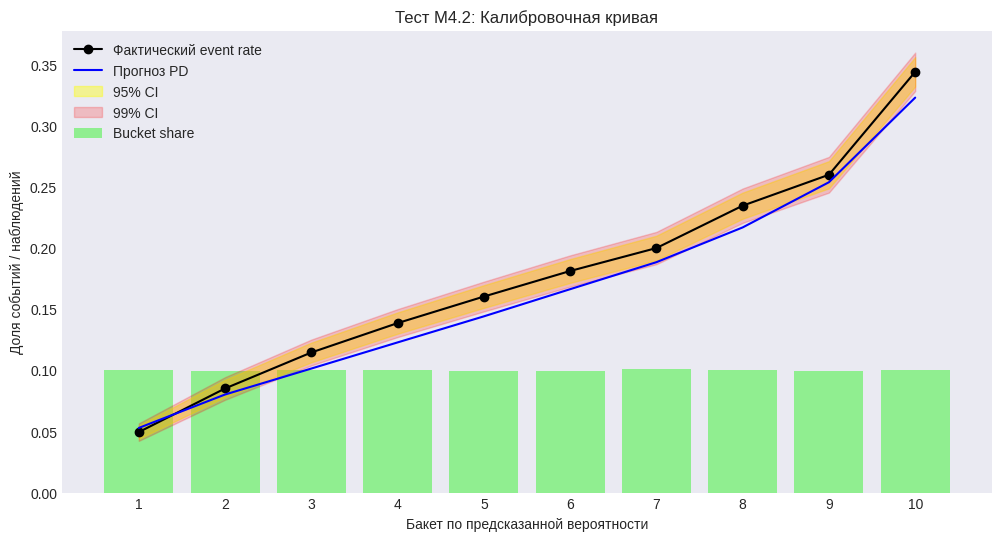


Итоговая оценка теста M4.2: 🟢 Зелёный (≤ 15%)


In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

n_bins = 10

calibration_df = pd.DataFrame({
    'prob': y_val_pred_proba,
    'target': y_val
})

calibration_df['bucket'] = pd.qcut(calibration_df['prob'], q=n_bins, duplicates='drop')

bucket_stats = calibration_df.groupby('bucket').agg(
    n_obs=('target', 'count'),
    n_event=('target', 'sum'),
    avg_prob=('prob', 'mean')
).reset_index()


bucket_stats['event_rate'] = bucket_stats['n_event'] / bucket_stats['n_obs']
bucket_stats['stderr'] = np.sqrt(bucket_stats['event_rate'] * (1 - bucket_stats['event_rate']) / bucket_stats['n_obs'])

bucket_stats['ci_95_low'] = bucket_stats['event_rate'] - norm.ppf(0.975) * bucket_stats['stderr']
bucket_stats['ci_95_high'] = bucket_stats['event_rate'] + norm.ppf(0.975) * bucket_stats['stderr']
bucket_stats['ci_99_low'] = bucket_stats['event_rate'] - norm.ppf(0.995) * bucket_stats['stderr']
bucket_stats['ci_99_high'] = bucket_stats['event_rate'] + norm.ppf(0.995) * bucket_stats['stderr']

bucket_stats['abs_rel_error'] = np.abs(bucket_stats['event_rate'] - bucket_stats['avg_prob']) / bucket_stats['event_rate']
bucket_stats['bad_flag'] = bucket_stats['abs_rel_error'] > 0.2

share_bad_buckets = bucket_stats['bad_flag'].mean()

if share_bad_buckets > 0.3:
    color = "🔴 Красный (более 30% точек вне точности)"
elif share_bad_buckets > 0.15:
    color = "🟡 Жёлтый (более 15%)"
else:
    color = "🟢 Зелёный (≤ 15%)"

plt.figure(figsize=(12, 6))
plt.bar(range(n_bins), bucket_stats['n_obs'] / bucket_stats['n_obs'].sum(), color='lightgreen', label='Bucket share')

plt.plot(range(n_bins), bucket_stats['event_rate'], marker='o', color='black', label='Фактический event rate')
plt.plot(range(n_bins), bucket_stats['avg_prob'], color='blue', label='Прогноз PD')

plt.fill_between(range(n_bins), bucket_stats['ci_95_low'], bucket_stats['ci_95_high'], color='yellow', alpha=0.4, label='95% CI')
plt.fill_between(range(n_bins), bucket_stats['ci_99_low'], bucket_stats['ci_99_high'], color='red', alpha=0.2, label='99% CI')

plt.xticks(range(n_bins), [f"{i+1}" for i in range(n_bins)])
plt.xlabel('Бакет по предсказанной вероятности')
plt.ylabel('Доля событий / наблюдений')
plt.title('Тест M4.2: Калибровочная кривая')
plt.legend()
plt.grid()
plt.show()

print(f"\nИтоговая оценка теста M4.2: {color}")


## Тест M5.1 Сравнение эффективности ранжирования модели на разработке и валидации

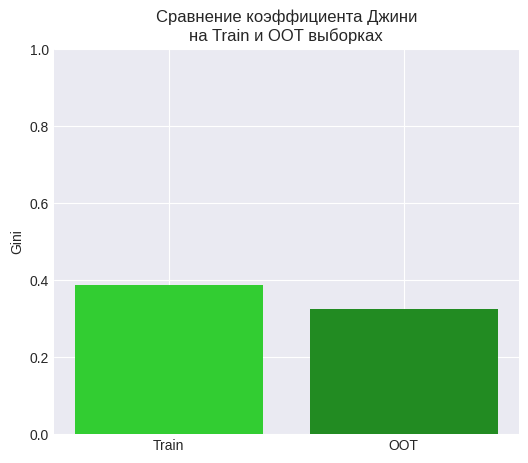

Gini (Train): 0.3881
Gini (OOT)  : 0.3258
Абсолютное снижение: 0.0623
Относительное снижение: 16.06%
Итоговая оценка теста M5.1: 🟡 Жёлтый


In [244]:
gini_train = 2 * roc_auc_score(y_train, final_model.predict_proba(X_train_woe)[:, 1]) - 1
gini_val   = 2 * roc_auc_score(y_val,   final_model.predict_proba(X_val)[:, 1]) - 1

abs_drop = gini_train - gini_val
rel_drop = abs_drop / gini_train

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.bar(['Train', 'OOT'], [gini_train, gini_val], color=['limegreen', 'forestgreen'])
plt.ylim(0, 1)
plt.title('Сравнение коэффициента Джини\nна Train и OOT выборках')
plt.ylabel('Gini')
plt.grid(True)
plt.show()

print(f"Gini (Train): {gini_train:.4f}")
print(f"Gini (OOT)  : {gini_val:.4f}")
print(f"Абсолютное снижение: {abs_drop:.4f}")
print(f"Относительное снижение: {rel_drop * 100:.2f}%")

if abs_drop > 0.05 and rel_drop > 0.20:
    color = "🔴 Красный"
elif abs_drop > 0.03 and rel_drop > 0.15:
    color = "🟡 Жёлтый"
else:
    color = "🟢 Зелёный"
print(f"Итоговая оценка теста M5.1: {color}")

## Тест 5.2 Сравнение эффективности ранжирования отдельных факторов модели на разработке и валидации

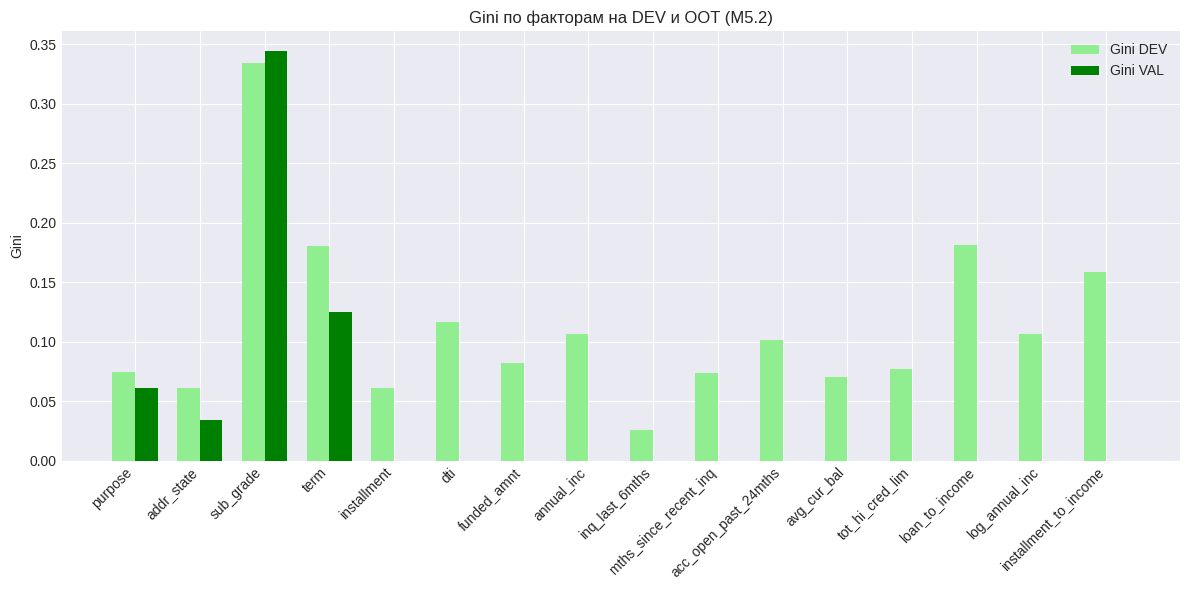

,Feature,Gini_DEV,Gini_VAL,Abs_diff,Rel_diff,Color
0,purpose,0.074703,0.061022,-0.013681,-0.183139,🟢 Зелёный
1,addr_state,0.061436,0.034332,-0.027104,-0.441175,🟢 Зелёный
2,sub_grade,0.333971,0.344126,0.010155,0.030406,🟢 Зелёный
3,term,0.180469,0.124954,-0.055515,-0.307615,🔴 Красный
4,installment,0.060723,0.000000,-0.060723,-1.000000,🔴 Красный
5,dti,0.116822,0.000000,-0.116822,-1.000000,🔴 Красный
6,funded_amnt,0.082144,0.000000,-0.082144,-1.000000,🔴 Красный
7,annual_inc,0.106502,0.000000,-0.106502,-1.000000,🔴 Красный
8,inq_last_6mths,0.025970,0.000000,-0.025970,-1.000000,🟢 Зелёный
9,mths_since_recent_inq,0.073793,0.000000,-0.073793,-1.000000,🔴 Красный



Итоговая оценка теста M5.2: 🔴 Красный


In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

gini_dev = {}
gini_val = {}

for feature in selected_features:
    auc_train = roc_auc_score(y_train, X_train_woe[feature])
    auc_val = roc_auc_score(y_val, X_val[feature])
    gini_dev[feature] = 2 * auc_train - 1
    gini_val[feature] = 2 * auc_val - 1

df_m5_2 = pd.DataFrame({
    'Feature': selected_features,
    'Gini_DEV': [gini_dev[f] for f in selected_features],
    'Gini_VAL': [gini_val[f] for f in selected_features]
})

df_m5_2['Abs_diff'] = df_m5_2['Gini_VAL'] - df_m5_2['Gini_DEV']
df_m5_2['Rel_diff'] = df_m5_2['Abs_diff'] / df_m5_2['Gini_DEV']

def assign_color(row):
    if row['Abs_diff'] < -0.05 and row['Rel_diff'] < -0.2:
        return '🔴 Красный'
    elif row['Abs_diff'] < -0.03 and row['Rel_diff'] < -0.15:
        return '🟡 Жёлтый'
    else:
        return '🟢 Зелёный'

df_m5_2['Color'] = df_m5_2.apply(assign_color, axis=1)

plt.figure(figsize=(12,6))
bar_width = 0.35
x = np.arange(len(df_m5_2))
plt.bar(x - bar_width/2, df_m5_2['Gini_DEV'], width=bar_width, label='Gini DEV', color='lightgreen')
plt.bar(x + bar_width/2, df_m5_2['Gini_VAL'], width=bar_width, label='Gini VAL', color='green')
plt.xticks(ticks=x, labels=df_m5_2['Feature'], rotation=45, ha='right')
plt.ylabel('Gini')
plt.title('Gini по факторам на DEV и OOT (M5.2)')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

display(df_m5_2[['Feature', 'Gini_DEV', 'Gini_VAL', 'Abs_diff', 'Rel_diff', 'Color']])

n_red = (df_m5_2['Color'] == '🔴 Красный').sum()
n_yellow = (df_m5_2['Color'] == '🟡 Жёлтый').sum()
n_total = len(df_m5_2)

if n_red > 0:
    final_color = '🔴 Красный'
elif n_yellow / n_total > 0.1:
    final_color = '🟡 Жёлтый'
else:
    final_color = '🟢 Зелёный'

print(f"\nИтоговая оценка теста M5.2: {final_color}")

 ## Интерпритация оценённой зависимости в терминах влияния отдельных признаков на вероятность дефолта.

In [246]:
# 1. Коэффициенты модели и соответствующие признаки
coef_table = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': final_model.coef_[0]
})
print("=== Коэффициенты логистической регрессии ===")
display(coef_table.sort_values(by='Coefficient', key=abs, ascending=False))

# 2. WOE-группировки
print("\n=== Примеры WOE-группировок ===")
for feature in selected_features:
    print(f"\nПризнак: {feature}")
    woe_map = woe_info.get(feature, {}).get('WOE', {})
    if isinstance(woe_map, dict):
        for k, v in woe_map.items():
            print(f"  {k}: {v:.4f}")
    else:
        print("  Нет информации")


=== Коэффициенты логистической регрессии ===


,Feature,Coefficient
1,addr_state,0.833556
2,sub_grade,0.749131
10,acc_open_past_24mths,0.682706
0,purpose,0.565027
9,mths_since_recent_inq,0.445692
3,term,0.427336
12,tot_hi_cred_lim,0.427212
7,annual_inc,0.419553
14,log_annual_inc,0.419553
5,dti,0.358852



=== Примеры WOE-группировок ===

Признак: purpose
  car: -0.5330
  credit_card: -0.2059
  debt_consolidation: 0.0689
  educational: 1.5014
  home_improvement: -0.1584
  house: 0.0039
  major_purchase: -0.2026
  medical: 0.1603
  moving: 0.1784
  other: 0.1252
  renewable_energy: 0.3317
  small_business: 0.6946
  vacation: -0.4181
  wedding: -0.3023

Признак: addr_state
  AK: -0.5531
  AL: 0.1960
  AR: 0.1791
  AZ: -0.0569
  CA: -0.0495
  CO: -0.3334
  CT: -0.0737
  DC: -0.6814
  DE: 0.0788
  FL: 0.1545
  GA: 0.0192
  HI: 0.1002
  IA: 4.6390
  IL: 0.0262
  IN: 0.0548
  KS: -0.1744
  KY: 0.1110
  LA: 0.0210
  MA: -0.0099
  MD: 0.1019
  MI: 0.0237
  MN: -0.0562
  MO: 0.1445
  MS: 0.7436
  MT: -0.7037
  NC: 0.0914
  NH: -0.1462
  NJ: 0.1704
  NM: -0.0081
  NV: 0.0994
  NY: 0.0622
  OH: 0.0500
  OK: -0.0158
  OR: -0.0549
  PA: 0.0655
  RI: -0.5229
  SC: -0.1616
  SD: -0.3080
  TN: 0.1010
  TX: -0.1679
  UT: -0.2521
  VA: 0.0544
  VT: -0.2845
  WA: -0.0932
  WI: -0.0366
  WV: -0.4787
  WY: 

### Интерпретация финальной логистической модели

Логистическая регрессия предсказывает логарифм шансов дефолта как линейную комбинацию WOE-преобразованных признаков. Чем выше коэффициент при признаке (в модуле), тем больше его вклад в решение модели.

Ниже представлены ключевые выводы по признакам с наибольшими коэффициентами:

#### `addr_state` (коэффициент: 0.83)
Регион заемщика оказывает значимое влияние. Например:
- IA (Айова): WOE = **4.64** → резко увеличивает вероятность дефолта.
- DC: WOE = **-0.68** → снижает вероятность дефолта.

#### `sub_grade` (0.75)
Подкласс кредитного рейтинга имеет чётко монотонную зависимость:
- A1 (лучший): WOE = **-1.99** → минимальный риск.
- G5 (худший): WOE = **1.16** → высокий риск.
  
#### `acc_open_past_24mths` (0.68)
Количество новых счетов за последние 2 года:
- Меньше 1–2: WOE отрицательные → снижают риск.
- Больше 4: WOE положительные → увеличивают риск.

#### `purpose` (0.57)
Цель займа влияет на риск:
- `educational`: WOE = **1.50** → высокий риск.
- `car`: WOE = **-0.53** → низкий риск.
- `small_business`: WOE = **0.69** → высокий риск.

#### `mths_since_recent_inq` (0.45)
Недавние кредитные запросы:
- Недавние (0–2 мес): WOE = **0.19** → повышают риск.
- Более 10 мес: WOE = **-0.15** → понижают риск.

#### `term` (0.43)
Срок кредита:
- 60 месяцев: WOE = **0.58** → значительно повышает риск по сравнению с 36 мес (WOE = -0.27).

#### `tot_hi_cred_lim` (0.43)
Общий кредитный лимит:
- Низкий лимит → WOE положительный → повышенный риск.
- Лимит выше 250k → WOE = **-0.29** → сниженный риск.

#### `loan_to_income`, `installment_to_income`, `log_annual_inc` (коэфф. 0.19–0.42)
Эти признаки отражают соотношение займа к доходу:
- Чем выше нагрузка на доход, тем выше WOE → тем выше риск.

#### Признаки с **отрицательными** коэффициентами:
- `avg_cur_bal` (–0.03) и `installment` (–0.02) почти не влияют.
- Отрицательные значения коэффициента говорят о том, что рост соответствующего WOE снижает вероятность дефолта.

---

### Вывод

Финальная модель логистической регрессии интерпретируема и логична:
- Основное влияние оказывают кредитный рейтинг (`sub_grade`), регион проживания, цель займа, долговая нагрузка и кредитная история.
- Направления WOE и коэффициентов модели в целом соответствуют здравому смыслу и банковской логике: высокие значения риска → повышают вероятность дефолта.

# 5. Неинтерпритируемая модель

## Обучение

In [247]:
!pip install catboost

0:	total: 147ms	remaining: 2m 26s
100:	total: 15.7s	remaining: 2m 19s
200:	total: 33.6s	remaining: 2m 13s
300:	total: 52.4s	remaining: 2m 1s
400:	total: 1m 10s	remaining: 1m 44s
500:	total: 1m 28s	remaining: 1m 27s
600:	total: 1m 48s	remaining: 1m 11s
700:	total: 2m 6s	remaining: 54s
800:	total: 2m 25s	remaining: 36.1s
900:	total: 2m 45s	remaining: 18.2s
999:	total: 3m 4s	remaining: 0us

CatBoost: Результаты на OOT
ROC-AUC: 0.6758
Gini:    0.3516
KS:      0.2598


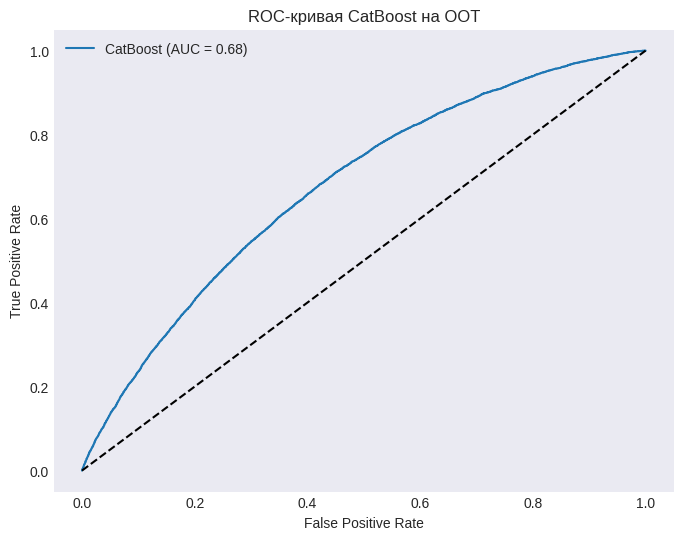

In [248]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

categorical_features = ['purpose', 'addr_state', 'sub_grade', 'term', 'home_ownership', 'emp_title', 'emp_length']
numeric_features_base = [
    'installment', 'dti', 'funded_amnt', 'annual_inc',
    'inq_last_6mths', 'mths_since_recent_inq',
    'acc_open_past_24mths', 'avg_cur_bal', 'tot_hi_cred_lim'
]
numeric_features_eng = ['loan_to_income', 'log_annual_inc', 'installment_to_income']
numeric_features = numeric_features_base + numeric_features_eng
all_features = categorical_features + numeric_features

def add_engineered(df):
    df['loan_to_income']        = df['funded_amnt'] / (df['annual_inc'] + 1)
    df['log_annual_inc']        = np.log(df['annual_inc'] + 1)
    df['installment_to_income'] = df['installment'] / ((df['annual_inc'] / 12) + 1)
    return df

def preprocess(df):
    for col in numeric_features_base:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = add_engineered(df)
    for col in numeric_features:
        df[col] = df[col].fillna(-1)
    for col in categorical_features:
        df[col] = df[col].astype(str).fillna('Unknown')
    return df

train = pd.read_csv('tr_for_students.csv', encoding='utf-8', sep=',')
val = pd.read_csv('vl_for_students.csv', encoding='mac_cyrillic', sep=';')

train = preprocess(train)
val = preprocess(val)

X_train = train[all_features]
y_train = train['def']
mask_val = val['def'].notna()
X_val = val.loc[mask_val, all_features]
y_val = val.loc[mask_val, 'def'].astype(int)

cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3.0,
    eval_metric='AUC',
    cat_features=categorical_features,
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train, y_train)

y_pred_proba = cat_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y_val, y_pred_proba)
gini = 2 * roc_auc - 1
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
ks_stat = max(tpr - fpr)

print("\nCatBoost: Результаты на OOT")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Gini:    {gini:.4f}")
print(f"KS:      {ks_stat:.4f}")

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая CatBoost на OOT')
plt.legend()
plt.grid()
plt.show()


## Тест M2.1: Эффективность ранжирования всей модели

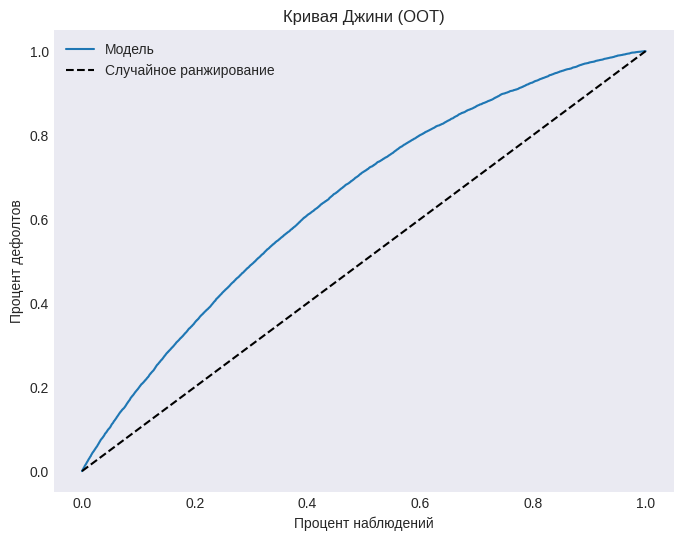

Gini: 0.3516
Светофор: 🟢


In [249]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

oos_results = pd.DataFrame({
    'y_true': y_val,
    'y_pred_proba': y_pred_proba
}).sort_values('y_pred_proba', ascending=False).reset_index(drop=True)

oos_results['cum_obs_pct'] = np.linspace(0, 1, len(oos_results))
oos_results['cum_bad_pct'] = oos_results['y_true'].cumsum() / oos_results['y_true'].sum()

plt.figure(figsize=(8,6))
plt.plot(oos_results['cum_obs_pct'], oos_results['cum_bad_pct'], label='Модель')
plt.plot([0,1], [0,1], 'k--', label='Случайное ранжирование')
plt.xlabel('Процент наблюдений')
plt.ylabel('Процент дефолтов')
plt.title('Кривая Джини (OOT)')
plt.legend()
plt.grid()
plt.show()

roc_auc = roc_auc_score(y_val, y_pred_proba)
gini_val = 2 * roc_auc - 1

if gini_val < 0.25:
    swt = '🔴'
elif gini_val < 0.35:
    swt = '🟡'
else:
    swt = '🟢'

print(f"Gini: {gini_val:.4f}")
print(f"Светофор: {swt}")

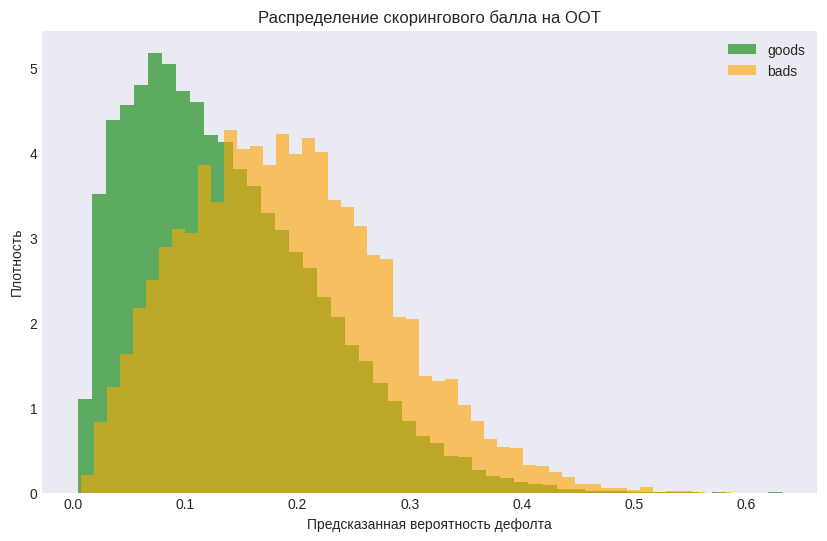

In [250]:
oos_results['good_bad'] = np.where(oos_results['y_true'] == 1, 'bads', 'goods')

plt.figure(figsize=(10,6))

plt.hist(
    oos_results[oos_results['good_bad'] == 'goods']['y_pred_proba'],
    bins=50, density=True, alpha=0.6, label='goods', color='green'
)

plt.hist(
    oos_results[oos_results['good_bad'] == 'bads']['y_pred_proba'],
    bins=50, density=True, alpha=0.6, label='bads', color='orange'
)

plt.title('Распределение скорингового балла на OOT')
plt.xlabel('Предсказанная вероятность дефолта')
plt.ylabel('Плотность')
plt.legend()
plt.grid()
plt.show()

## Тест M2.2 Эффективность ранжирования отдельных факторов


 Gini по признакам на OOT


,Gini,Color
acc_open_past_24mths,0.162018,🟢
installment_to_income,0.152579,🟢
loan_to_income,0.151928,🟢
term,0.124954,🟢
dti,0.122734,🟢
inq_last_6mths,0.090302,🟢
installment,0.042745,🟡
funded_amnt,0.042178,🟡
mths_since_recent_inq,-0.033540,🔴
annual_inc,-0.102126,🔴



Красных факторов: 5
Жёлтых факторов: 2
Зелёных факторов: 6

Итоговая оценка теста M2.2: 🔴


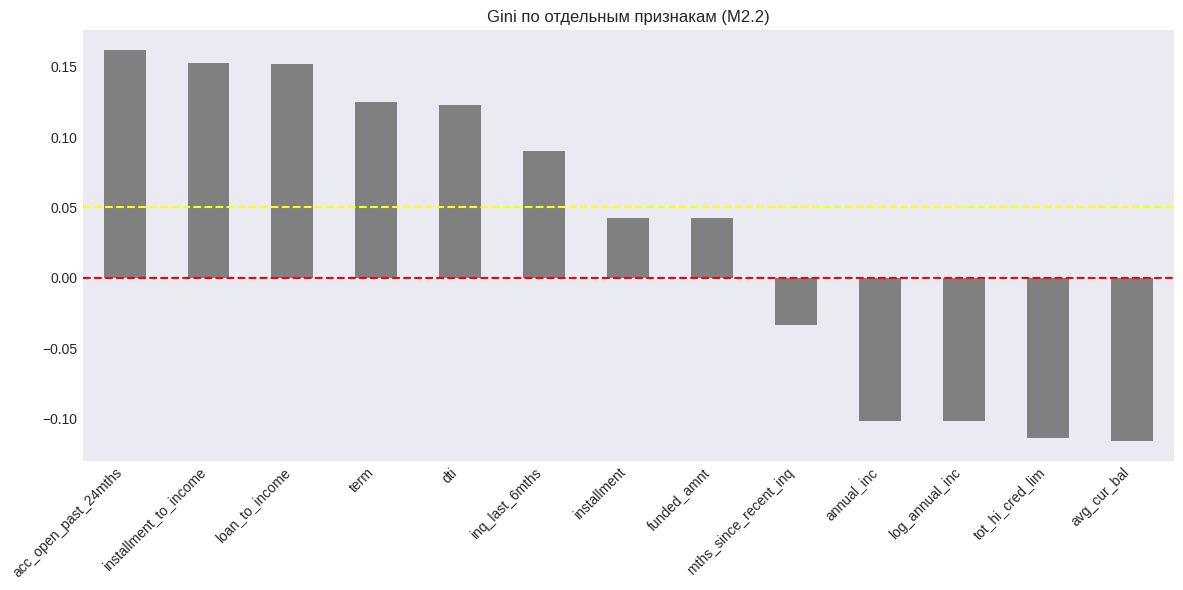

In [251]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

gini_factors = {}

for feature in all_features:
    try:
        auc = roc_auc_score(y_val, X_val[feature])
        gini = 2 * auc - 1
        gini_factors[feature] = gini
    except:
        continue

gini_factors_df = pd.DataFrame.from_dict(gini_factors, orient='index', columns=['Gini']).sort_values(by='Gini', ascending=False)

def assign_color(g):
    if g < 0:
        return '🔴'
    elif g <= 0.05:
        return '🟡'
    else:
        return '🟢'

gini_factors_df['Color'] = gini_factors_df['Gini'].apply(assign_color)

num_red = (gini_factors_df['Color'] == '🔴').sum()
num_yellow = (gini_factors_df['Color'] == '🟡').sum()
num_green = (gini_factors_df['Color'] == '🟢').sum()

if num_red > len(gini_factors_df) * 0.2:
    final_color = '🔴'
elif num_yellow / len(gini_factors_df) > 0.1:
    final_color = '🟡'
else:
    final_color = '🟢'

print("\n Gini по признакам на OOT")
display(gini_factors_df)
print(f"\nКрасных факторов: {num_red}")
print(f"Жёлтых факторов: {num_yellow}")
print(f"Зелёных факторов: {num_green}")
print(f"\nИтоговая оценка теста M2.2: {final_color}")

plt.figure(figsize=(12,6))
gini_factors_df['Gini'].plot(kind='bar', color='gray')
plt.axhline(0.05, color='yellow', linestyle='--')
plt.axhline(0, color='red', linestyle='--')
plt.title('Gini по отдельным признакам (M2.2)')
plt.xticks(rotation=45, ha='right')
plt.grid()
plt.tight_layout()
plt.show()

## Тест M2.5 Анализ вкладов факторов в формирование Джини модели

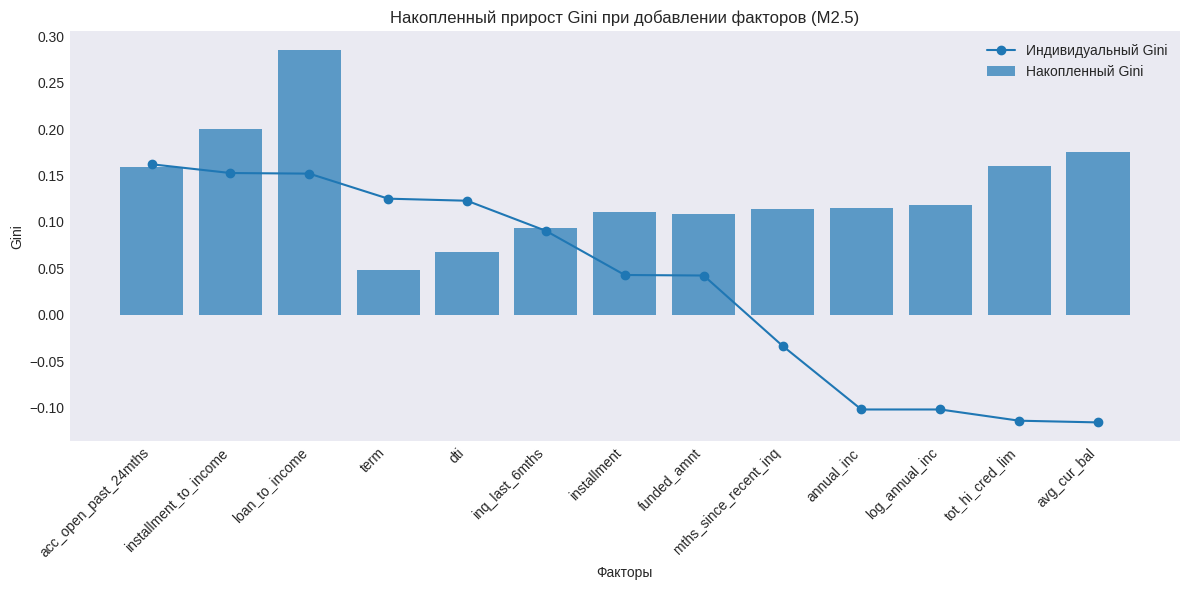


Накопленный прирост Gini по факторам (M2.5)


,Feature,Individual_Gini,Cumulative_Gini
0,acc_open_past_24mths,0.162018,0.158749
1,installment_to_income,0.152579,0.200161
2,loan_to_income,0.151928,0.285306
3,term,0.124954,0.047630
4,dti,0.122734,0.067766
5,inq_last_6mths,0.090302,0.093654
6,installment,0.042745,0.110401
7,funded_amnt,0.042178,0.108923
8,mths_since_recent_inq,-0.033540,0.114124
9,annual_inc,-0.102126,0.114924


In [252]:
import numpy as np
import matplotlib.pyplot as plt

features_ordered = gini_factors_df.sort_values(by='Gini', ascending=False).index.tolist()

cumulative_gini = []
individual_gini = []

for i in range(1, len(features_ordered) + 1):
    selected = features_ordered[:i]
    model_temp = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=3.0,
        eval_metric='AUC',
        cat_features=[f for f in categorical_features if f in selected],
        random_seed=42,
        verbose=0
    )
    model_temp.fit(X_train[selected], y_train)
    probs = model_temp.predict_proba(X_val[selected])[:, 1]
    auc = roc_auc_score(y_val, probs)
    gini = 2 * auc - 1
    cumulative_gini.append(gini)

individual_gini = gini_factors_df.loc[features_ordered, 'Gini'].values

plt.figure(figsize=(12,6))
plt.bar(features_ordered, cumulative_gini, label='Накопленный Gini', alpha=0.7)
plt.plot(features_ordered, individual_gini, marker='o', label='Индивидуальный Gini')
plt.title('Накопленный прирост Gini при добавлении факторов (M2.5)')
plt.xlabel('Факторы')
plt.ylabel('Gini')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

gini_uplift_df = pd.DataFrame({
    'Feature': features_ordered,
    'Individual_Gini': individual_gini,
    'Cumulative_Gini': cumulative_gini
})

print("\nНакопленный прирост Gini по факторам (M2.5)")
display(gini_uplift_df)

## Тест M2.4 Динамика коэффициента Джини по времени

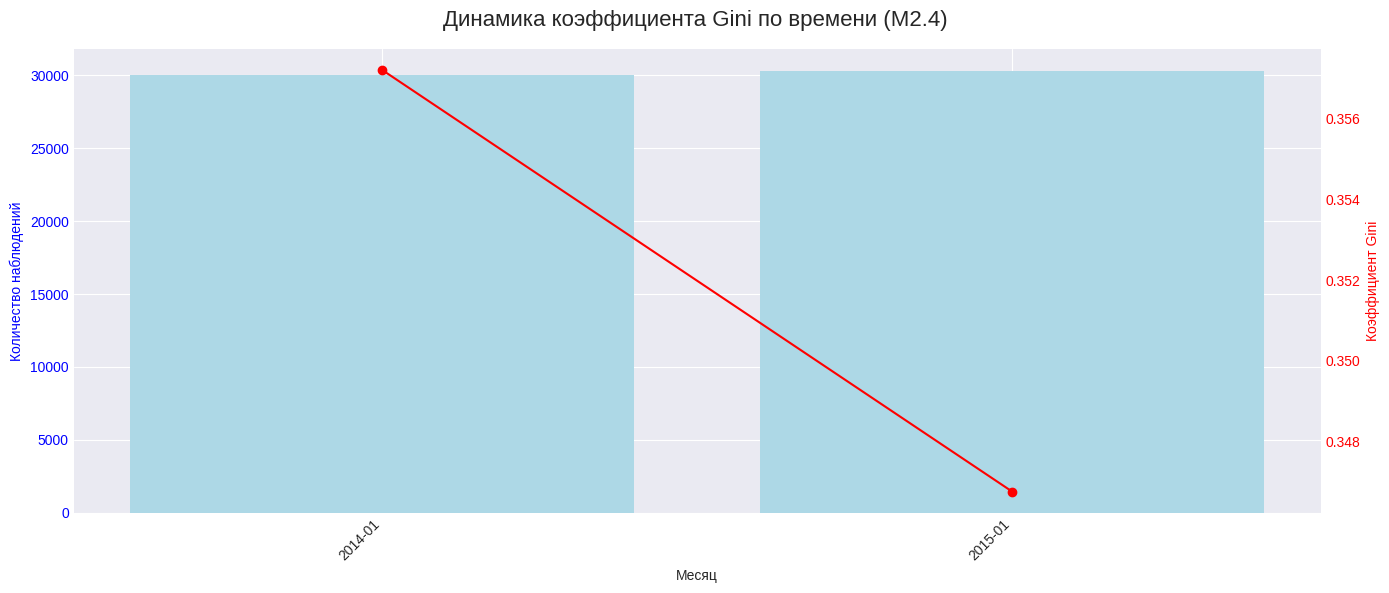


 Gini по месяцам (M2.4)


,Month,Gini,Observations
0,2014-01,0.357206,30022
1,2015-01,0.346762,30301


In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

val_filtered = val.loc[mask_val].copy()
val_filtered['y_true'] = y_val
val_filtered['y_pred_proba'] = y_pred_proba
val_filtered['issue_d'] = pd.to_datetime(val_filtered['issue_d'])
val_filtered['issue_month'] = val_filtered['issue_d'].dt.to_period('M')

gini_by_month = []
obs_by_month = []
months = sorted(val_filtered['issue_month'].unique())

for month in months:
    temp = val_filtered[val_filtered['issue_month'] == month]
    if len(temp) >= 30:
        auc = roc_auc_score(temp['y_true'], temp['y_pred_proba'])
        gini = 2 * auc - 1
        gini_by_month.append(gini)
        obs_by_month.append(len(temp))
    else:
        gini_by_month.append(np.nan)
        obs_by_month.append(len(temp))

gini_dynamics = pd.DataFrame({
    'Month': [str(m) for m in months],
    'Gini': gini_by_month,
    'Observations': obs_by_month
}).dropna()

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.bar(gini_dynamics['Month'], gini_dynamics['Observations'], color='lightblue')
ax1.set_ylabel('Количество наблюдений', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Месяц')
ax1.set_xticklabels(gini_dynamics['Month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(gini_dynamics['Month'], gini_dynamics['Gini'], marker='o', color='red')
ax2.set_ylabel('Коэффициент Gini', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.suptitle('Динамика коэффициента Gini по времени (M2.4)', fontsize=16)
fig.tight_layout()
plt.grid()
plt.show()

print("\n Gini по месяцам (M2.4)")
display(gini_dynamics)

## Тест 3.1 Анализ корректности дискретного преобразования факторов

In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

features_to_check = numeric_features + categorical_features
results = []

for feature in features_to_check:
    df_temp = val.loc[mask_val].copy()
    df_temp['target'] = y_val
    try:
        df_temp['bin'] = pd.qcut(df_temp[feature], q=10, duplicates='drop')
    except Exception:
        continue

    bucket_stats = df_temp.groupby('bin', observed=True)['target'].mean().reset_index()
    bucket_stats['count'] = df_temp.groupby('bin', observed=True)['target'].count().values
    rel_diffs = bucket_stats['target'].diff().abs() / (bucket_stats['target'].shift(1) + 1e-6)
    non_monotonic = rel_diffs > 0.1
    share_non_monotonic = non_monotonic.sum() / len(rel_diffs)

    color = '🟢 Зелёный'
    if share_non_monotonic > 0.1:
        color = '🟡 Жёлтый'
    if share_non_monotonic > 0.2:
        color = '🔴 Красный'

    results.append({
        'Feature': feature,
        'Non_monotonic_changes': non_monotonic.sum(),
        'Share_non_monotonic': round(share_non_monotonic, 2),
        'Color': color
    })

monotonic_df = pd.DataFrame(results).sort_values('Share_non_monotonic', ascending=False)
print("Результаты теста M3.1: Проверка монотонности признаков")
display(monotonic_df)

num_red = (monotonic_df['Color'] == '🔴 Красный').sum()
num_yellow = (monotonic_df['Color'] == '🟡 Жёлтый').sum()

if num_red > 0.2 * len(monotonic_df):
    overall_color = '🔴 Красный'
elif num_yellow > 0.1 * len(monotonic_df):
    overall_color = '🟡 Жёлтый'
else:
    overall_color = '🟢 Зелёный'

print(f"\nИтоговая оценка теста M3.1: {overall_color}")

Результаты теста M3.1: Проверка монотонности признаков


,Feature,Non_monotonic_changes,Share_non_monotonic,Color
1,dti,4,0.67,🔴 Красный
4,inq_last_6mths,2,0.67,🔴 Красный
9,loan_to_income,5,0.50,🔴 Красный
6,acc_open_past_24mths,4,0.44,🔴 Красный
11,installment_to_income,3,0.30,🔴 Красный
7,avg_cur_bal,2,0.20,🟡 Жёлтый
0,installment,2,0.20,🟡 Жёлтый
2,funded_amnt,2,0.20,🟡 Жёлтый
8,tot_hi_cred_lim,2,0.20,🟡 Жёлтый
5,mths_since_recent_inq,2,0.20,🟡 Жёлтый



Итоговая оценка теста M3.1: 🔴 Красный


## Тест M4.1 Сравнение прогнозного и фактического TR на уровне выборки

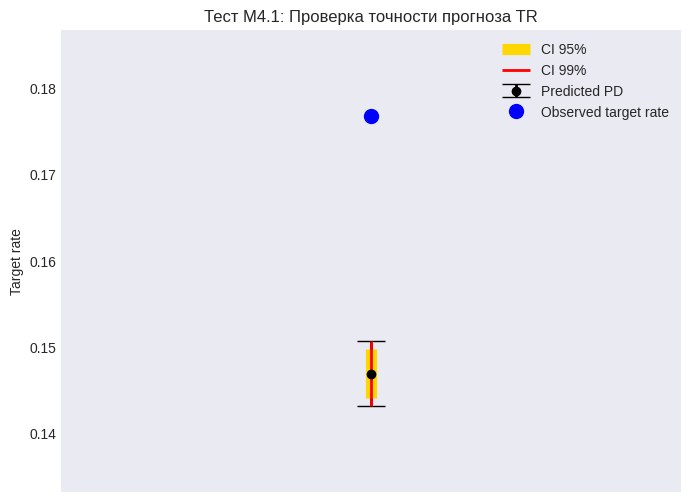


Средний прогноз вероятности дефолта (P): 0.1470
Фактический уровень дефолтов (TR): 0.1767
95% доверительный интервал: (np.float64(0.14413161562208565), np.float64(0.14978261609165733))
99% доверительный интервал: (np.float64(0.14323783493557174), np.float64(0.15067639677817124))
Относительная ошибка: 16.86%
Итог: 🟡 Жёлтый (ошибка 10%-20%)


In [255]:
import matplotlib.pyplot as plt
import numpy as np

P = y_pred_proba.mean()
TR = y_val.mean()
n = len(y_pred_proba)
se = np.sqrt(P * (1 - P) / n)

ci_95 = (P - 1.96 * se, P + 1.96 * se)
ci_99 = (P - 2.58 * se, P + 2.58 * se)

rel_error = abs(TR - P) / TR * 100

plt.figure(figsize=(8, 6))

plt.errorbar(1, P, yerr=[[P - ci_99[0]], [ci_99[1] - P]],
             fmt='o', color='black', capsize=10, label='Predicted PD', lw=2)
plt.errorbar(1, TR, fmt='o', color='blue', label='Observed target rate', markersize=10)

plt.vlines(1, ci_95[0], ci_95[1], colors='gold', lw=8, label='CI 95%')
plt.vlines(1, ci_99[0], ci_99[1], colors='red', lw=2, label='CI 99%')

plt.xlim(0.5, 1.5)
plt.ylim(min(ci_99[0], TR) - 0.01, max(ci_99[1], TR) + 0.01)
plt.ylabel('Target rate')
plt.xticks([])
plt.title('Тест M4.1: Проверка точности прогноза TR')
plt.legend()
plt.grid()
plt.show()

print(f"\nСредний прогноз вероятности дефолта (P): {P:.4f}")
print(f"Фактический уровень дефолтов (TR): {TR:.4f}")
print(f"95% доверительный интервал: {ci_95}")
print(f"99% доверительный интервал: {ci_99}")
print(f"Относительная ошибка: {rel_error:.2f}%")

if rel_error > 20:
    print("Итог: 🔴 Красный (ошибка > 20%)")
elif rel_error > 10:
    print("Итог: 🟡 Жёлтый (ошибка 10%-20%)")
else:
    print("Итог: 🟢 Зелёный (ошибка ≤10%)")


## Тест M4.2 Тест формы калибровочной кривой

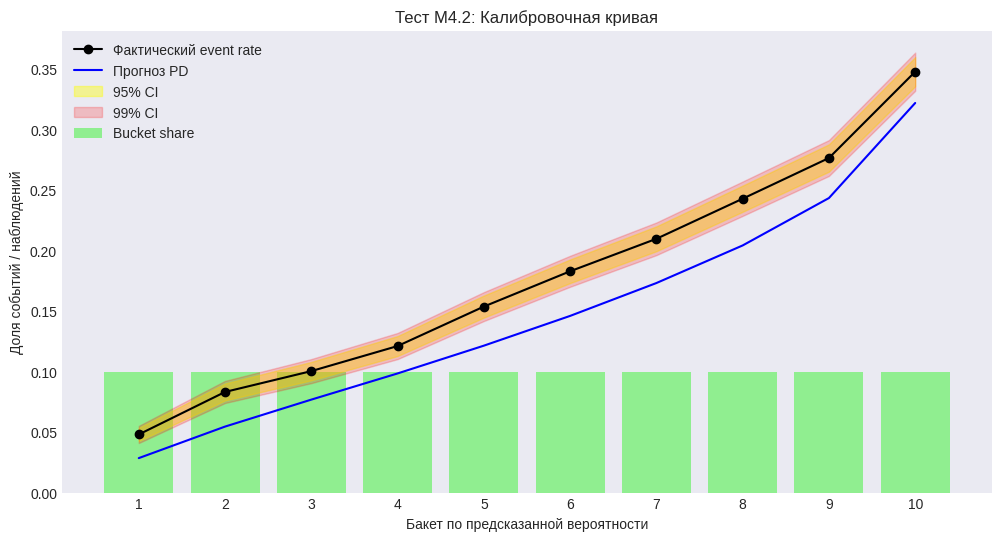


Итоговая оценка теста M4.2: 🔴 Красный (более 30% точек вне точности)


In [256]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

n_bins = 10

calibration_df = pd.DataFrame({
    'prob': y_pred_proba,
    'target': y_val
})

calibration_df['bucket'] = pd.qcut(calibration_df['prob'], q=n_bins, duplicates='drop')

bucket_stats = calibration_df.groupby('bucket', observed=True).agg(
    n_obs=('target', 'count'),
    n_event=('target', 'sum'),
    avg_prob=('prob', 'mean')
).reset_index()

bucket_stats['event_rate'] = bucket_stats['n_event'] / bucket_stats['n_obs']
bucket_stats['stderr'] = np.sqrt(bucket_stats['event_rate'] * (1 - bucket_stats['event_rate']) / bucket_stats['n_obs'])

bucket_stats['ci_95_low'] = bucket_stats['event_rate'] - norm.ppf(0.975) * bucket_stats['stderr']
bucket_stats['ci_95_high'] = bucket_stats['event_rate'] + norm.ppf(0.975) * bucket_stats['stderr']
bucket_stats['ci_99_low'] = bucket_stats['event_rate'] - norm.ppf(0.995) * bucket_stats['stderr']
bucket_stats['ci_99_high'] = bucket_stats['event_rate'] + norm.ppf(0.995) * bucket_stats['stderr']

bucket_stats['abs_rel_error'] = np.abs(bucket_stats['event_rate'] - bucket_stats['avg_prob']) / bucket_stats['event_rate']
bucket_stats['bad_flag'] = bucket_stats['abs_rel_error'] > 0.2

share_bad_buckets = bucket_stats['bad_flag'].mean()

if share_bad_buckets > 0.3:
    color = "🔴 Красный (более 30% точек вне точности)"
elif share_bad_buckets > 0.15:
    color = "🟡 Жёлтый (более 15%)"
else:
    color = "🟢 Зелёный (≤ 15%)"

plt.figure(figsize=(12, 6))
plt.bar(range(n_bins), bucket_stats['n_obs'] / bucket_stats['n_obs'].sum(), color='lightgreen', label='Bucket share')
plt.plot(range(n_bins), bucket_stats['event_rate'], marker='o', color='black', label='Фактический event rate')
plt.plot(range(n_bins), bucket_stats['avg_prob'], color='blue', label='Прогноз PD')

plt.fill_between(range(n_bins), bucket_stats['ci_95_low'], bucket_stats['ci_95_high'], color='yellow', alpha=0.4, label='95% CI')
plt.fill_between(range(n_bins), bucket_stats['ci_99_low'], bucket_stats['ci_99_high'], color='red', alpha=0.2, label='99% CI')

plt.xticks(range(n_bins), [f"{i+1}" for i in range(n_bins)])
plt.xlabel('Бакет по предсказанной вероятности')
plt.ylabel('Доля событий / наблюдений')
plt.title('Тест M4.2: Калибровочная кривая')
plt.legend()
plt.grid()
plt.show()

print(f"\nИтоговая оценка теста M4.2: {color}")

## Тест M5.1 Сравнение эффективности ранжирования модели на разработке и валидации

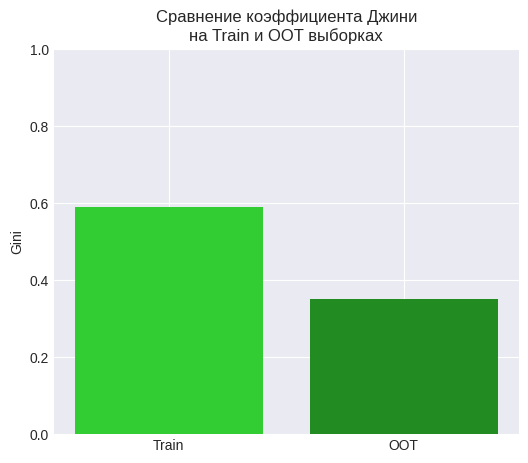

Gini (Train): 0.5895
Gini (OOT)  : 0.3516
Абсолютное снижение: 0.2379
Относительное снижение: 40.36%
Итоговая оценка теста M5.1: 🔴 Красный


In [257]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

gini_train = 2 * roc_auc_score(y_train, cat_model.predict_proba(X_train)[:, 1]) - 1
gini_val   = 2 * roc_auc_score(y_val,   cat_model.predict_proba(X_val)[:, 1]) - 1

abs_drop = gini_train - gini_val
rel_drop = abs_drop / gini_train

plt.figure(figsize=(6,5))
plt.bar(['Train', 'OOT'], [gini_train, gini_val], color=['limegreen', 'forestgreen'])
plt.ylim(0, 1)
plt.title('Сравнение коэффициента Джини\nна Train и OOT выборках')
plt.ylabel('Gini')
plt.grid(True)
plt.show()

print(f"Gini (Train): {gini_train:.4f}")
print(f"Gini (OOT)  : {gini_val:.4f}")
print(f"Абсолютное снижение: {abs_drop:.4f}")
print(f"Относительное снижение: {rel_drop * 100:.2f}%")

if abs_drop > 0.05 and rel_drop > 0.20:
    color = "🔴 Красный"
elif abs_drop > 0.03 and rel_drop > 0.15:
    color = "🟡 Жёлтый"
else:
    color = "🟢 Зелёный"
print(f"Итоговая оценка теста M5.1: {color}")

## Тест 5.2 Сравнение эффективности ранжирования отдельных факторов модели на разработке и валидации

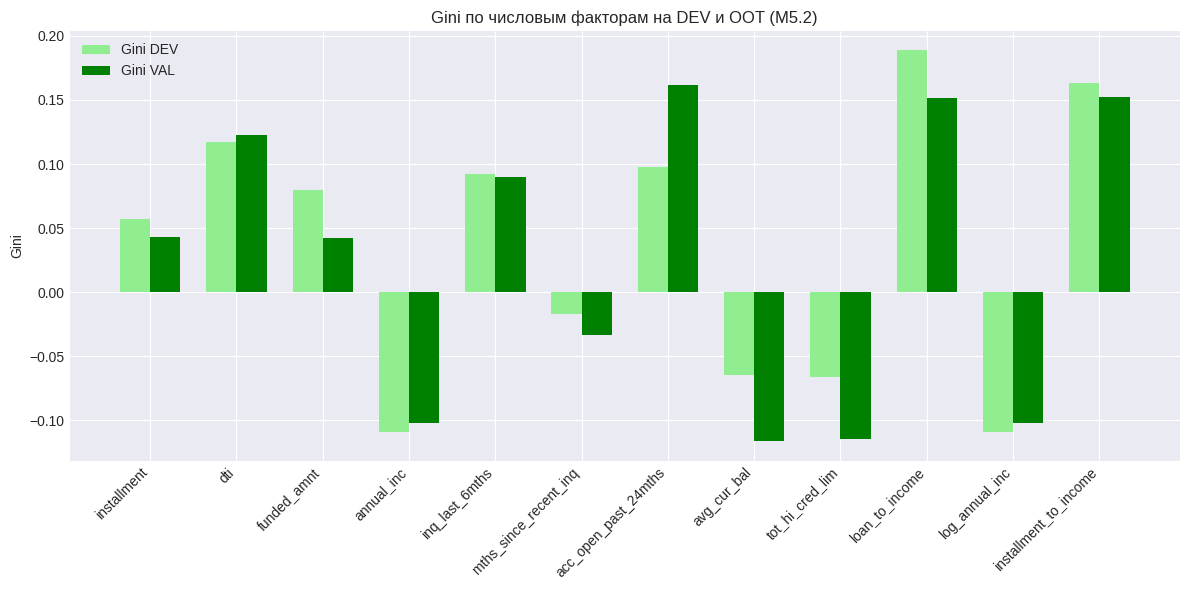

,Feature,Gini_DEV,Gini_VAL,Abs_diff,Rel_diff,Color
0,installment,0.057009,0.042745,-0.014264,-0.250208,🟢 Зелёный
1,dti,0.117336,0.122734,0.005398,0.046003,🟢 Зелёный
2,funded_amnt,0.079949,0.042178,-0.037771,-0.472439,🟡 Жёлтый
3,annual_inc,-0.108928,-0.102126,0.006801,-0.062440,🟢 Зелёный
4,inq_last_6mths,0.092509,0.090302,-0.002207,-0.023856,🟢 Зелёный
5,mths_since_recent_inq,-0.016670,-0.033540,-0.016870,1.012006,🟢 Зелёный
6,acc_open_past_24mths,0.097512,0.162018,0.064506,0.661522,🟢 Зелёный
7,avg_cur_bal,-0.064709,-0.116045,-0.051335,0.793320,🟢 Зелёный
8,tot_hi_cred_lim,-0.066404,-0.114206,-0.047802,0.719864,🟢 Зелёный
9,loan_to_income,0.188709,0.151928,-0.036781,-0.194909,🟡 Жёлтый



Итоговая оценка теста M5.2: 🟡 Жёлтый


In [258]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

gini_dev = {}
gini_val = {}

for feature in numeric_features:
    auc_train = roc_auc_score(y_train, X_train[feature])
    auc_val = roc_auc_score(y_val, X_val[feature])
    gini_dev[feature] = 2 * auc_train - 1
    gini_val[feature] = 2 * auc_val - 1

df_m5_2 = pd.DataFrame({
    'Feature': numeric_features,
    'Gini_DEV': [gini_dev[f] for f in numeric_features],
    'Gini_VAL': [gini_val[f] for f in numeric_features]
})

df_m5_2['Abs_diff'] = df_m5_2['Gini_VAL'] - df_m5_2['Gini_DEV']
df_m5_2['Rel_diff'] = df_m5_2['Abs_diff'] / df_m5_2['Gini_DEV']

def assign_color(row):
    if row['Abs_diff'] < -0.05 and row['Rel_diff'] < -0.2:
        return '🔴 Красный'
    elif row['Abs_diff'] < -0.03 and row['Rel_diff'] < -0.15:
        return '🟡 Жёлтый'
    else:
        return '🟢 Зелёный'

df_m5_2['Color'] = df_m5_2.apply(assign_color, axis=1)

plt.figure(figsize=(12,6))
bar_width = 0.35
x = np.arange(len(df_m5_2))
plt.bar(x - bar_width/2, df_m5_2['Gini_DEV'], width=bar_width, label='Gini DEV', color='lightgreen')
plt.bar(x + bar_width/2, df_m5_2['Gini_VAL'], width=bar_width, label='Gini VAL', color='green')
plt.xticks(ticks=x, labels=df_m5_2['Feature'], rotation=45, ha='right')
plt.ylabel('Gini')
plt.title('Gini по числовым факторам на DEV и OOT (M5.2)')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

display(df_m5_2[['Feature', 'Gini_DEV', 'Gini_VAL', 'Abs_diff', 'Rel_diff', 'Color']])

n_red = (df_m5_2['Color'] == '🔴 Красный').sum()
n_yellow = (df_m5_2['Color'] == '🟡 Жёлтый').sum()
n_total = len(df_m5_2)

if n_red > 0:
    final_color = '🔴 Красный'
elif n_yellow / n_total > 0.1:
    final_color = '🟡 Жёлтый'
else:
    final_color = '🟢 Зелёный'

print(f"\nИтоговая оценка теста M5.2: {final_color}")


 # 6. Сравнение с интерпретируемой моделью, описание результатов.


## Сравнение с интерпретируемой моделью

В качестве основной (интерпретируемой) модели была построена логистическая регрессия на WOE-признаках, в то время как в роли неинтерпретируемой модели выступил CatBoost — градиентный бустинг по решающим деревьям.

### Качество на отложенной (OOT) выборке

| Метрика         | Логистическая регрессия | CatBoost |
|-----------------|--------------------------|----------|
| ROC-AUC         | 0.6629                   | **0.6758** |
| Gini            | 0.3258                   | **0.3516** |
| KS-статистика   | 0.2331                   | **0.2598** |

CatBoost показал **лучшее качество ранжирования** по всем основным метрикам, особенно по Gini (+2.6 п.п.) и KS-статистике (+0.03), что свидетельствует о его более высокой способности различать «хороших» и «плохих» заёмщиков.

---

### Сравнение по результатам валидационных тестов

| Тест   | Описание                                          | Логистическая регрессия | CatBoost |
|--------|---------------------------------------------------|--------------------------|----------|
| M2.1   | Gini для модели                                   | 🟡                       | 🟢       |
| M2.2   | Gini по признакам                                 | 🟡                       | 🔴       |
| M3.1   | Монотонность признаков                            | 🟢                       | 🔴       |
| M4.1   | Точность прогноза среднего уровня дефолта         | 🟢                       | 🟡       |
| M4.2   | Калибровка по бакетам                             | 🟢                       | 🔴       |
| M5.1   | Сравнение Gini на train и OOT                     | 🟡                       | 🔴       |
| M5.2   | Сравнение Gini факторов на train и OOT            | 🔴                       | 🟡       |

Хотя CatBoost выигрывает по финальному качеству, валидационные тесты выявили **некоторые проблемы с устойчивостью и калибровкой** модели:
- Значительное ухудшение монотонности (M3.1)
- Падение стабильности факторов (M5.2)
- Проблемы калибровки вероятностей (M4.2)

---

### Вывод

CatBoost превосходит интерпретируемую модель по качеству предсказаний, но уступает ей по стабильности и прозрачности. Поэтому выбор модели зависит от приоритетов:
- **CatBoost** — если важна высокая точность и допускается «чёрный ящик».
- **Логистическая регрессия с WOE** — если критична интерпретируемость, надёжность и соответствие требованиям регуляторов.

# 7. Расчёт ожидаемой прибыли от кредитования

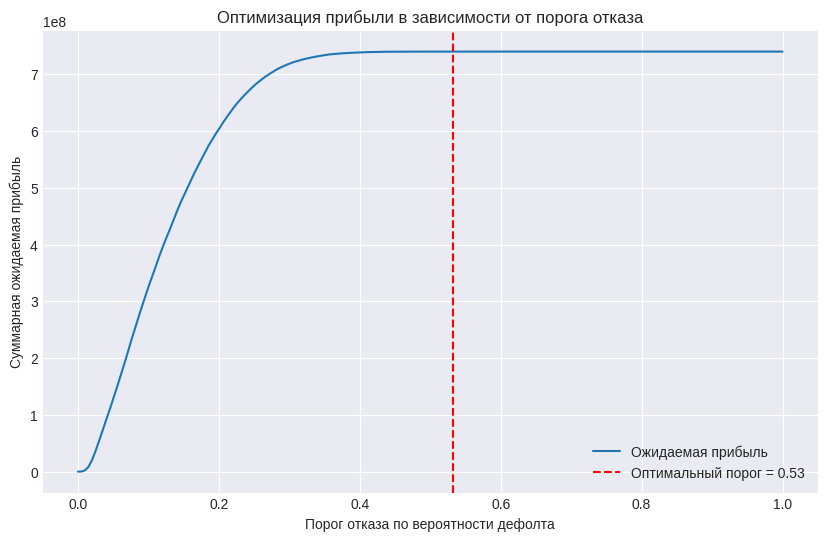

Оптимальный порог отказа: 0.533
Максимальная ожидаемая прибыль (LGD = 100%): 739,936,992 у.е.


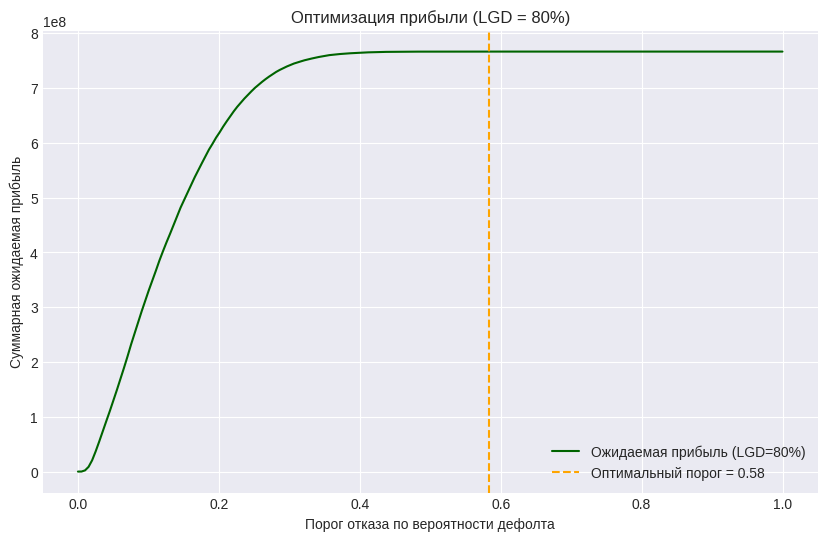

Оптимальный порог отказа при LGD=80%: 0.583
Максимальная ожидаемая прибыль (LGD = 80%): 766,717,026 у.е.


In [260]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

val_profit = val.copy()
val_profit = val_profit.loc[y_val.index].copy()
val_profit['y_true'] = y_val
val_profit['y_pred_proba'] = y_pred_proba

r = 0.13
val_profit['expected_profit'] = val_profit['funded_amnt'] * (
    (1 + r) * (1 - val_profit['y_pred_proba']) - val_profit['y_pred_proba']
)

thresholds = np.linspace(0, 1, 200)
profits = []

for t in thresholds:
    accepted = val_profit[val_profit['y_pred_proba'] <= t]
    total_profit = accepted['expected_profit'].sum()
    profits.append(total_profit)

best_idx = np.argmax(profits)
best_threshold = thresholds[best_idx]
max_profit = profits[best_idx]

plt.figure(figsize=(10,6))
plt.plot(thresholds, profits, label='Ожидаемая прибыль')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Оптимальный порог = {best_threshold:.2f}')
plt.xlabel('Порог отказа по вероятности дефолта')
plt.ylabel('Суммарная ожидаемая прибыль')
plt.title('Оптимизация прибыли в зависимости от порога отказа')
plt.legend()
plt.grid(True)
plt.show()

print(f"Оптимальный порог отказа: {best_threshold:.3f}")
print(f"Максимальная ожидаемая прибыль (LGD = 100%): {max_profit:,.0f} у.е.")

val_profit['expected_profit_lgd80'] = val_profit['funded_amnt'] * (
    (1 + r) * (1 - val_profit['y_pred_proba']) - 0.8 * val_profit['y_pred_proba']
)

profits_lgd80 = []
for t in thresholds:
    accepted = val_profit[val_profit['y_pred_proba'] <= t]
    total_profit = accepted['expected_profit_lgd80'].sum()
    profits_lgd80.append(total_profit)

best_idx_80 = np.argmax(profits_lgd80)
best_threshold_80 = thresholds[best_idx_80]
max_profit_80 = profits_lgd80[best_idx_80]

plt.figure(figsize=(10,6))
plt.plot(thresholds, profits_lgd80, label='Ожидаемая прибыль (LGD=80%)', color='darkgreen')
plt.axvline(best_threshold_80, color='orange', linestyle='--', label=f'Оптимальный порог = {best_threshold_80:.2f}')
plt.xlabel('Порог отказа по вероятности дефолта')
plt.ylabel('Суммарная ожидаемая прибыль')
plt.title('Оптимизация прибыли (LGD = 80%)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Оптимальный порог отказа при LGD=80%: {best_threshold_80:.3f}")
print(f"Максимальная ожидаемая прибыль (LGD = 80%): {max_profit_80:,.0f} у.е.")
